## **1. 문제 정의 및 데이터 이해**

**목표 설정**

- 비즈니스 문제: 통신사 고객 이탈을 예측하여 선제적 유지 전략 수립
- 분석 목표: 이탈에 영향을 미치는 주요 요인 파악 및 이탈 예측 모델 구축
- 성공 지표: 모델 정확도, Precision/Recall, F1-score, 비즈니스 액션 가능성 등

**데이터셋 구조 파악**

- churn-80.csv (훈련/검증용), churn-20.csv (최종 테스트용) 파일 로드
- 데이터 크기, 변수 개수, 데이터 타입 확인
- 각 변수의 의미와 비즈니스 맥락 이해

### 데이터셋 구조 파악

In [15]:

import pandas as pd

#churn-80.csv (훈련/검증용), churn-20.csv (최종 테스트용) 파일 로드
df = pd.read_csv('churn-bigml-80.csv')
df1 = pd.read_csv('churn-bigml-20.csv')

#데이터 크기, 변수 개수, 데이터 타입 확인
df.head(20)
df.shape
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

#각 변수의 의미와 비즈니스 맥락 이해

| 컬럼명                        | 의미                        |
| -------------------------- | ------------------------- |
| **State**                  | 고객이 거주하는 주(State)         |
| **Account length**         | 고객 계정 유지 기간(일)            |
| **Area code**              | 지역 전화 코드                  |
| **International plan**     | 국제전화 요금제 사용 여부 (Yes/No)   |
| **Voice mail plan**        | 음성 사서함 요금제 사용 여부 (Yes/No) |
| **Number vmail messages**  | 음성 사서함 메시지 수              |
| **Total day minutes**      | 주간 통화 총 시간(분)             |
| **Total day calls**        | 주간 통화 횟수                  |
| **Total day charge**       | 주간 통화 요금                  |
| **Total eve minutes**      | 저녁 통화 총 시간(분)             |
| **Total eve calls**        | 저녁 통화 횟수                  |
| **Total eve charge**       | 저녁 통화 요금                  |
| **Total night minutes**    | 야간 통화 총 시간(분)             |
| **Total night calls**      | 야간 통화 횟수                  |
| **Total night charge**     | 야간 통화 요금                  |
| **Total intl minutes**     | 국제 통화 총 시간(분)             |
| **Total intl calls**       | 국제 통화 횟수                  |
| **Total intl charge**      | 국제 통화 요금                  |
| **Customer service calls** | 고객센터 문의 횟수                |
| **Churn**                  | 고객 이탈 여부 (True/False)     |


## **2. 데이터 전처리**

**결측치 처리**

- 결측치 존재 여부 확인
- 결측치 처리 전략 수립: 삭제, 평균/중앙값 대체, 또는 별도 카테고리 생성
- 처리 방법에 대한 근거 수립

**이상치 탐지 및 처리**

- 이상치가 실제 오류인지 극단값인지 판단
- 비즈니스 맥락을 고려한 처리 방법 결정 (유지/제거/변환 등)

**데이터 타입 변환**

- 범주형 변수(State, International plan, Voice mail plan) 식별
- 수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
- 필요시 변수 타입 변환 및 인코딩
    - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등

### 결측치 처리

In [16]:
#결측치 존재 여부 확인
df.isnull().sum()

#결측치 없음
df.isnull().any()

State                     False
Account length            False
Area code                 False
International plan        False
Voice mail plan           False
Number vmail messages     False
Total day minutes         False
Total day calls           False
Total day charge          False
Total eve minutes         False
Total eve calls           False
Total eve charge          False
Total night minutes       False
Total night calls         False
Total night charge        False
Total intl minutes        False
Total intl calls          False
Total intl charge         False
Customer service calls    False
Churn                     False
dtype: bool

### 이상치 탐지 및 처리

In [17]:
#이상치가 실제 오류인지 극단값인지 판단
#이상치는 수치형 변수에서만 확인할 수 있으므로 수치형 변수 선택
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

#IQR을 사용하여 이상치가 있는 컬럼들 확인
def find_outlier_columns_iqr(df, num_cols):
    outlier_cols = []

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if ((df[col] < lower) | (df[col] > upper)).any():
            outlier_cols.append(col)

    return outlier_cols


#이상치가 있는 컬럼 총 15개
outlier_columns = find_outlier_columns_iqr(df, num_cols)
outlier_columns



['Account length',
 'Number vmail messages',
 'Total day minutes',
 'Total day calls',
 'Total day charge',
 'Total eve minutes',
 'Total eve calls',
 'Total eve charge',
 'Total night minutes',
 'Total night calls',
 'Total night charge',
 'Total intl minutes',
 'Total intl calls',
 'Total intl charge',
 'Customer service calls']

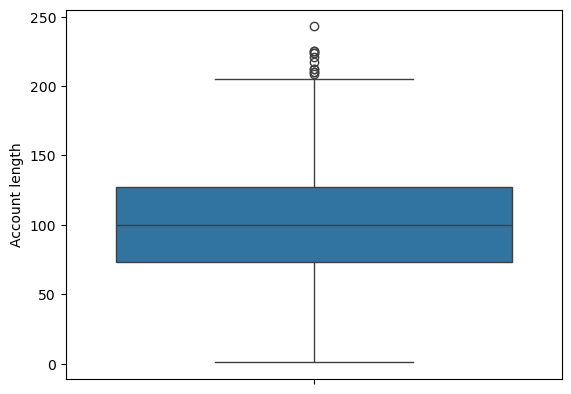

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.boxplot(df['Account length'])
plt.show()

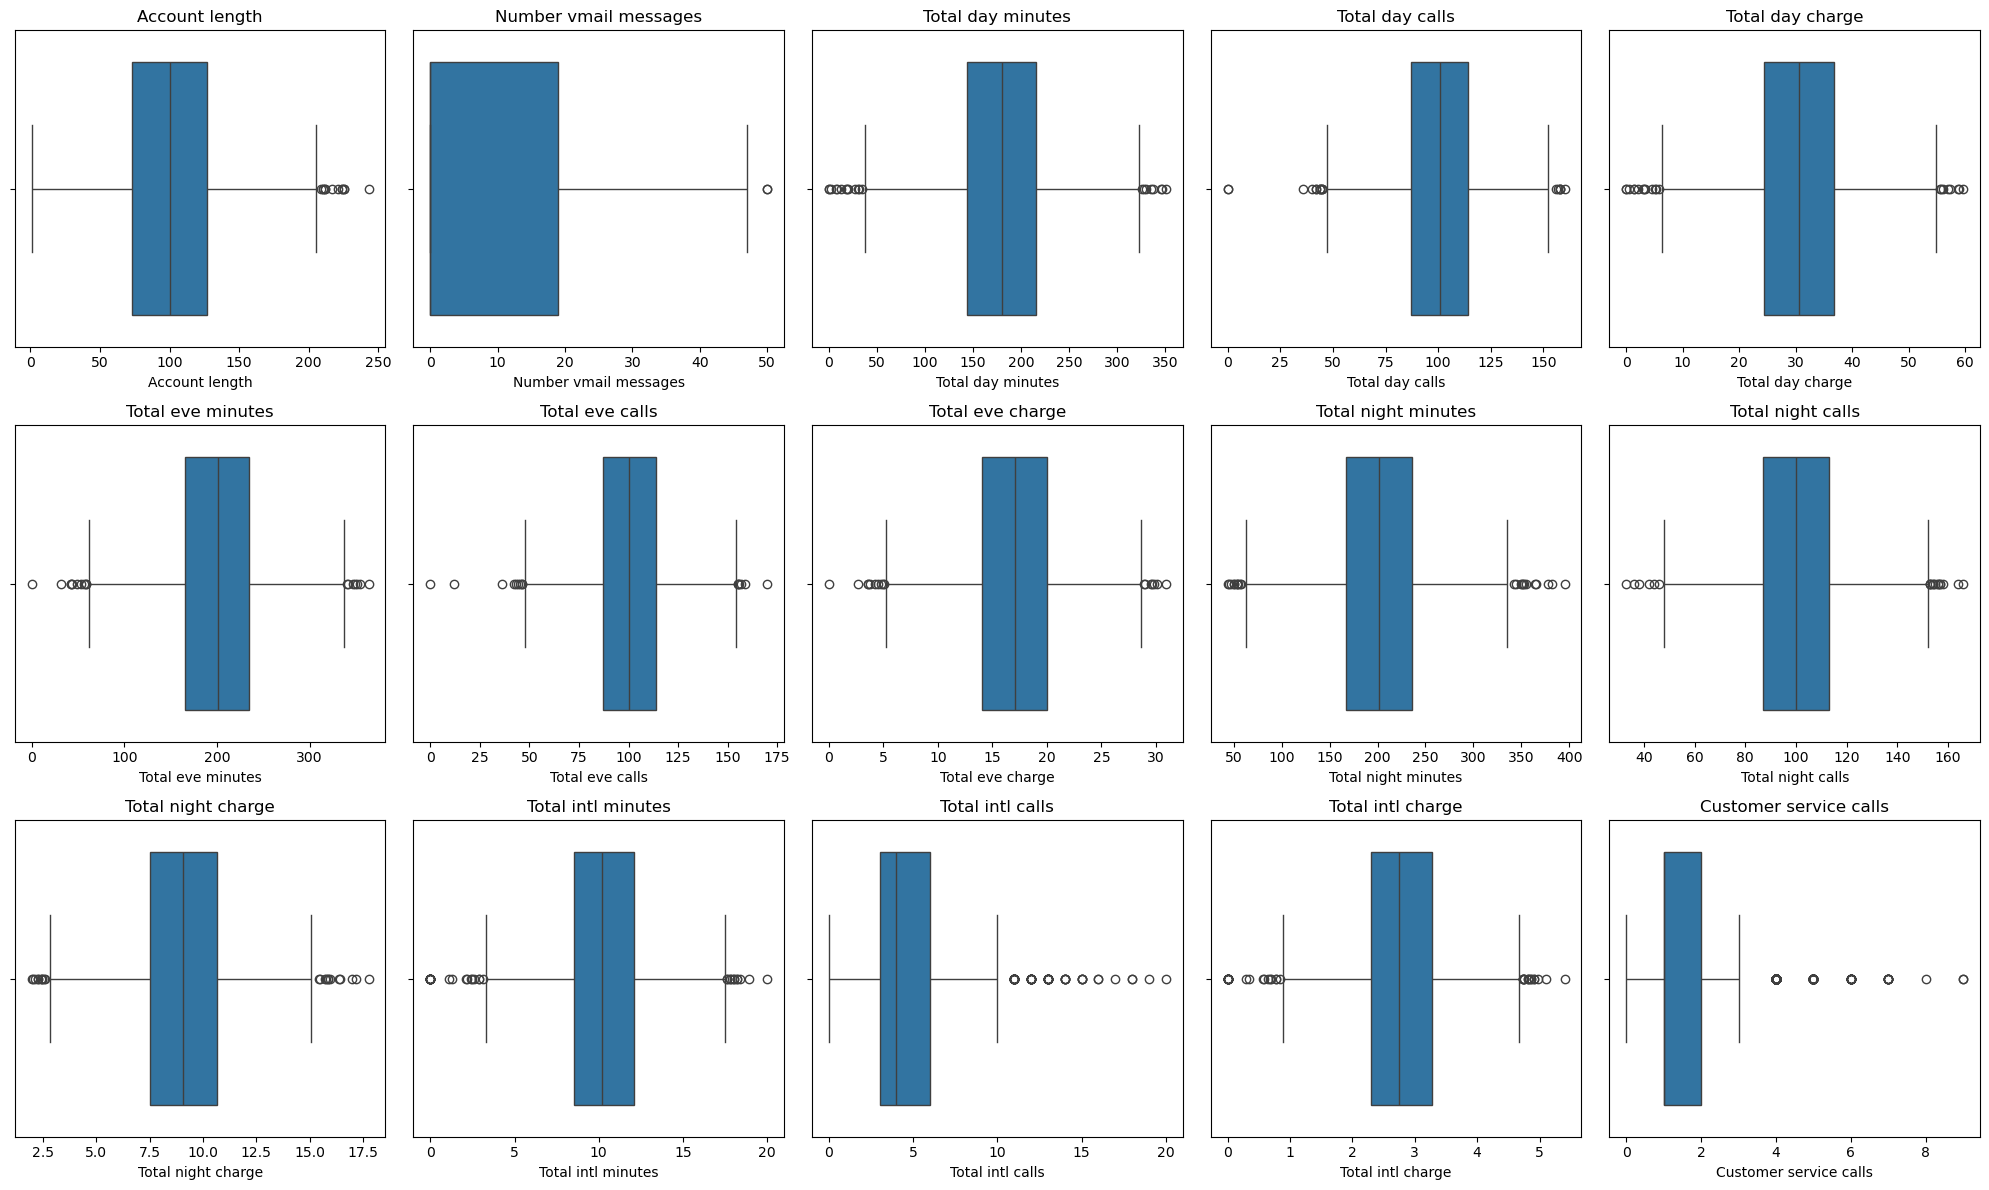

In [19]:

#이상치가 있는 컬럼들에 대해 박스플롯 그림
outlier_cols = outlier_columns


fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#비즈니스 맥락을 고려한 처리 방법 결정 (유지/제거/변환 등)

각각 컬럼의 이상치를 확인해보았을 때 특별히 오류값이라고 판단되거나 의미없는 값이라고 생각되는 컬럼이 없어서
우선 컬럼들은 다 유지하기로 결정함


### 데이터 타입 변환
- 범주형 변수(State, International plan, Voice mail plan) 식별
- 수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
- 필요시 변수 타입 변환 및 인코딩
    - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등

In [20]:
#수치형 변수 식별
num_cols = df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

#범주형 변수 식별
df.dtypes
notnum_cols = df.select_dtypes(exclude=['int64','float64']).columns
print(notnum_cols)

#수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
df.describe()


Index(['Account length', 'Area code', 'Number vmail messages',
       'Total day minutes', 'Total day calls', 'Total day charge',
       'Total eve minutes', 'Total eve calls', 'Total eve charge',
       'Total night minutes', 'Total night calls', 'Total night charge',
       'Total intl minutes', 'Total intl calls', 'Total intl charge',
       'Customer service calls'],
      dtype='object')
Index(['State', 'International plan', 'Voice mail plan', 'Churn'], dtype='object')


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [21]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

#필요시 변수 타입 변환 및 인코딩  - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등
df.dtypes
notnum_cols = df.select_dtypes(exclude=['int64','float64']).columns
print(notnum_cols)

#'State', 'International plan', 'Voice mail plan', 'Churn'
for col in notnum_cols:
    print(f"범주형 변수 값 종류 : {df[col].unique()}")
    print(f"범주형 변수 값 분포 : {df[col].value_counts()}")




Index(['State', 'International plan', 'Voice mail plan', 'Churn'], dtype='object')
범주형 변수 값 종류 : ['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'WV' 'RI' 'IA' 'MT' 'ID' 'VT' 'VA'
 'TX' 'FL' 'CO' 'AZ' 'NE' 'WY' 'IL' 'NH' 'LA' 'GA' 'AK' 'MD' 'AR' 'WI'
 'OR' 'DE' 'IN' 'UT' 'CA' 'SD' 'NC' 'WA' 'MN' 'NM' 'NV' 'DC' 'NY' 'KY'
 'ME' 'MS' 'MI' 'SC' 'TN' 'PA' 'HI' 'ND' 'CT']
범주형 변수 값 분포 : State
WV    88
MN    70
NY    68
VA    67
AL    66
OH    66
WY    66
OR    62
NV    61
WI    61
MD    60
UT    60
CO    59
CT    59
MI    58
VT    57
ID    56
NC    56
TX    55
FL    54
IN    54
MT    53
OK    52
MA    52
KS    52
MO    51
DE    51
NJ    50
SC    49
SD    49
ME    49
GA    49
RI    48
MS    48
WA    48
AR    47
IL    45
DC    45
AZ    45
NE    45
HI    44
NM    44
ND    44
AK    43
KY    43
NH    43
TN    41
IA    38
PA    36
LA    35
CA    24
Name: count, dtype: int64
범주형 변수 값 종류 : ['No' 'Yes']
범주형 변수 값 분포 : International plan
No     2396
Yes     270
Name: count, dtype: int64
범주형 변수 값 종류 : ['Yes' 'No']
범

In [22]:
#원본값을 그대로 두고, bin 값으로 컬럼 생성하여 변경
df['International_plan_bin'] = df['International plan'].map({'No': 0, 'Yes': 1})
df['Voice_mail_plan_bin'] = df['Voice mail plan'].map({'No': 0, 'Yes': 1})

In [23]:
#데이터 확인
df.head(10)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,International_plan_bin,Voice_mail_plan_bin
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,0,1
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,0,1
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,1,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1,0
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False,1,0
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False,0,1
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False,1,0
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False,1,1
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False,0,0


## **3. EDA**

**단변량 분석 (Univariate Analysis)**

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

**이변량 분석 (Bivariate Analysis)**

- 수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
- 범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교
- 통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인
- 핵심 인사이트 도출: "고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상" 등

**다변량 분석 (Multivariate Analysis)**

- 상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화
- 다중공선성 확인 (주간/야간 통화시간-요금 간 높은 상관관계 등)
- Pair plot으로 변수 간 관계 시각화
- PCA를 통한 차원 축소 및 주요 성분 해석 (선택적)

**비즈니스 인사이트 도출**

- 이탈 고객의 주요 특징 3-5가지 정리
- 지역별/요금제별 이탈률 차이 분석
- 고위험 고객 프로필 정의
- EDA 결과를 바탕으로 가설 수립

### 단변량 분석 (Univariate Analysis)

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

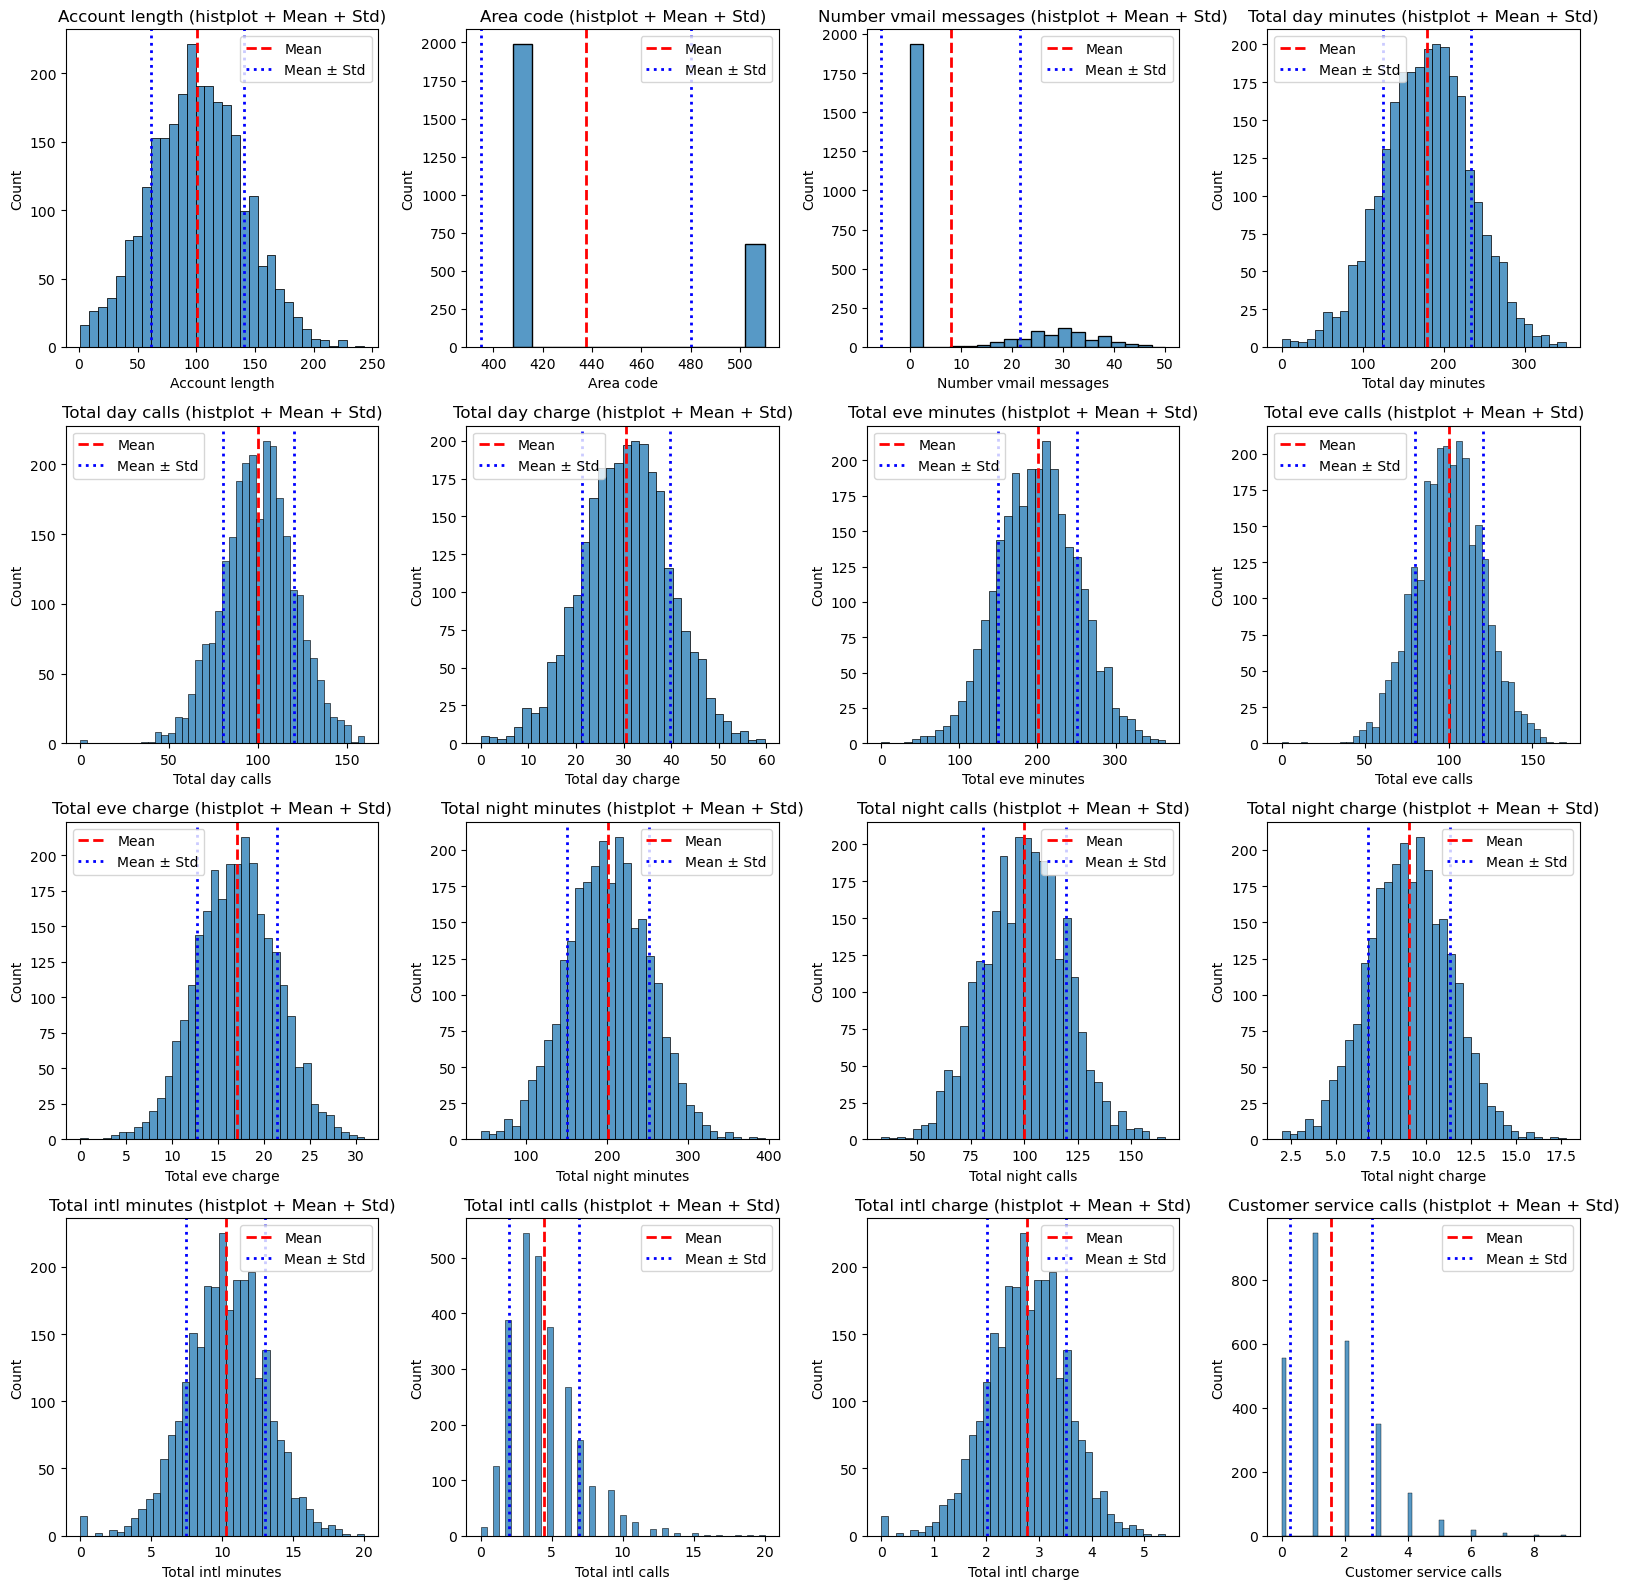

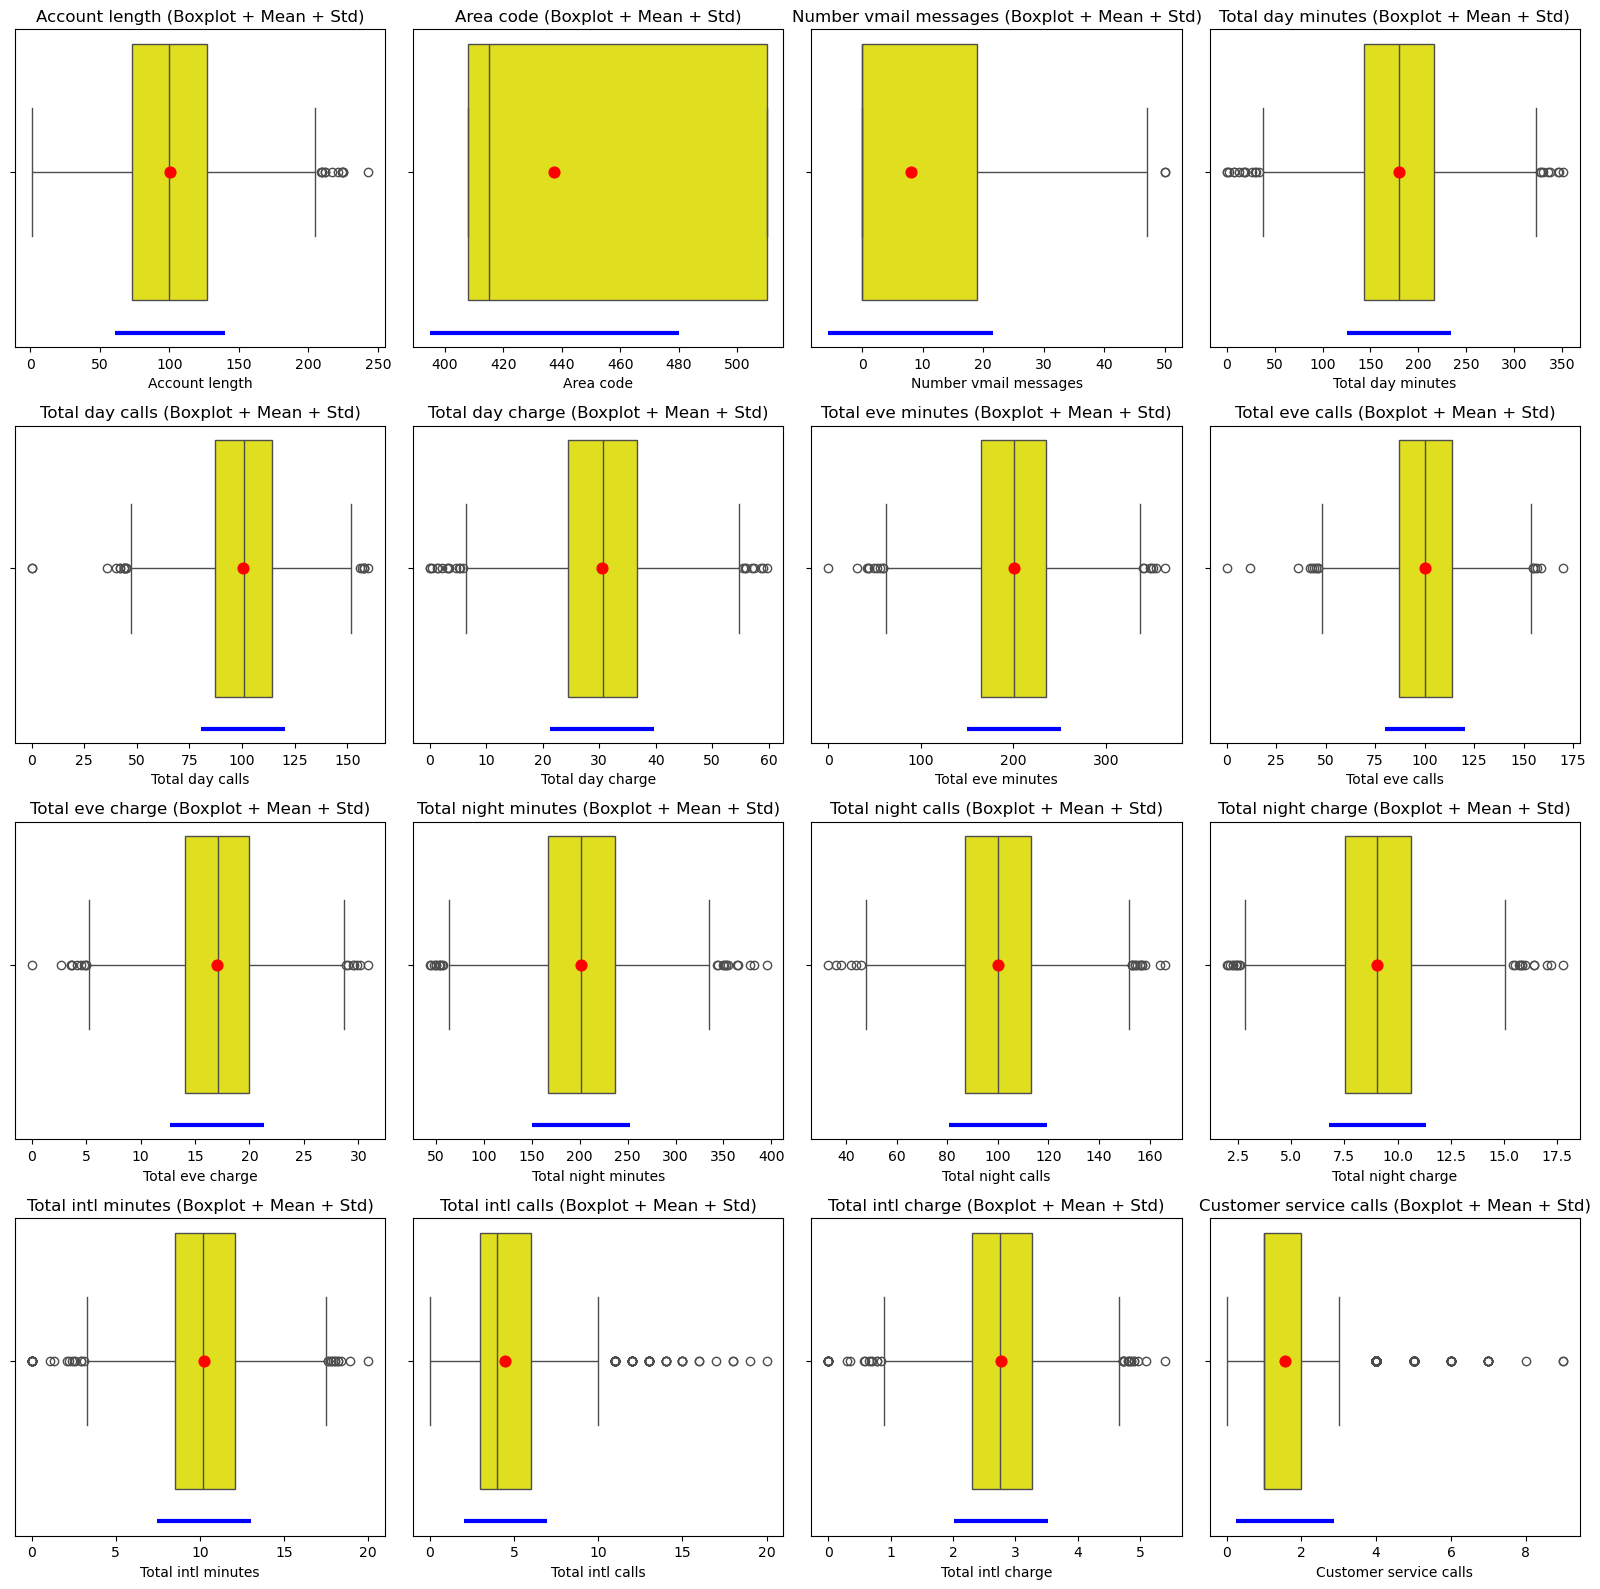

In [24]:

#수치형 변수: 히스토그램 분포 확인

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    mean_val = df[col].mean()
    std_val = df[col].std()
    sns.histplot(df[col], ax=axes[i])

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')

    axes[i].axvline(mean_val - std_val, color='blue', linestyle=':', linewidth=2, label='Mean ± Std')
    axes[i].axvline(mean_val + std_val, color='blue', linestyle=':', linewidth=2)
    axes[i].set_title(col)

    axes[i].legend()
    axes[i].set_title(f'{col} (histplot + Mean + Std)')

plt.tight_layout()
plt.show()

#수치형 변수 : 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
fig, axes = plt.subplots(4, 4, figsize=(16,16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='yellow')

    mean_val = df[col].mean()
    std_val = df[col].std()
    axes[i].scatter(mean_val, 0, color='red', s=60, zorder=3)
    axes[i].hlines(
    y=0.5,
    xmin=mean_val - std_val,
    xmax=mean_val + std_val,
    color='blue',
    linewidth=3,
    zorder=2
)

    axes[i].set_title(f'{col} (Boxplot + Mean + Std)')

plt.tight_layout()
plt.show()

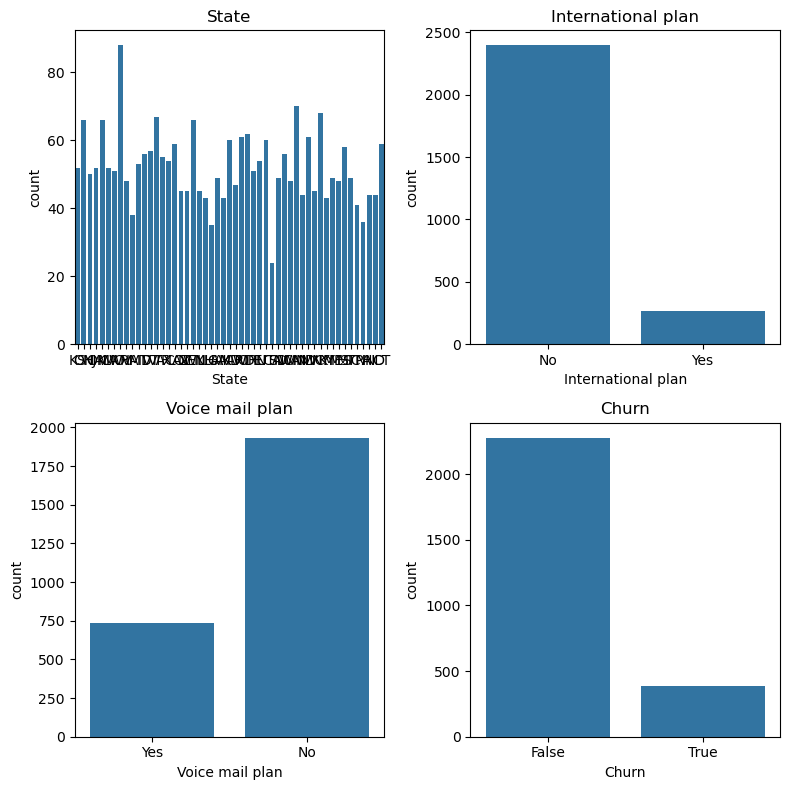

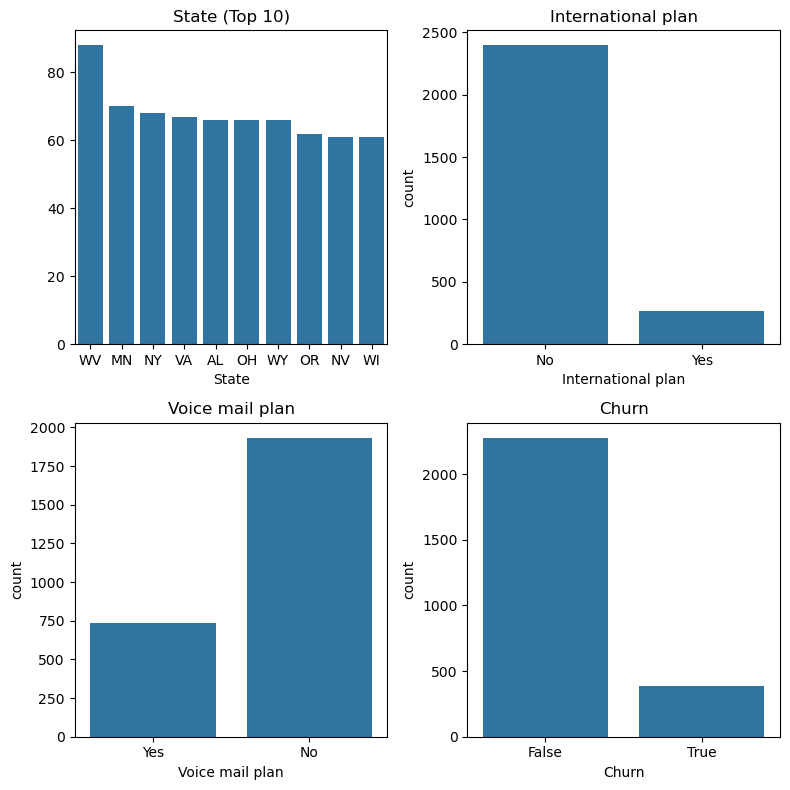

In [25]:
#범주형 변수 막대그래프 확인

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, col in enumerate(notnum_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()


#state 컬럼값이 너무 많아서 상위20개만 확인
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, col in enumerate(notnum_cols):
    if col == 'State':
        counts = df[col].value_counts().head(10)
        sns.barplot(
            x=counts.index,
            y=counts.values,
            ax=axes[i]
        )
        axes[i].set_title(f'{col} (Top 10)')
    else:
        sns.countplot(x=col, data=df, ax=axes[i])
        axes[i].set_title(col)


plt.tight_layout()
plt.show()


범주형 변수 중에서
state는 값이 다양하고 분포도 크게 차이가 나지 않아서 의미가 없어보이지만,

단일값으로만 확정할 수는 없기에 이변량 또는 다변량에서 한번 더 확인을 해보고 분석에서 제외해도 될지를 선택해도 좋을 것 같습니다.

<function matplotlib.pyplot.show(close=None, block=None)>

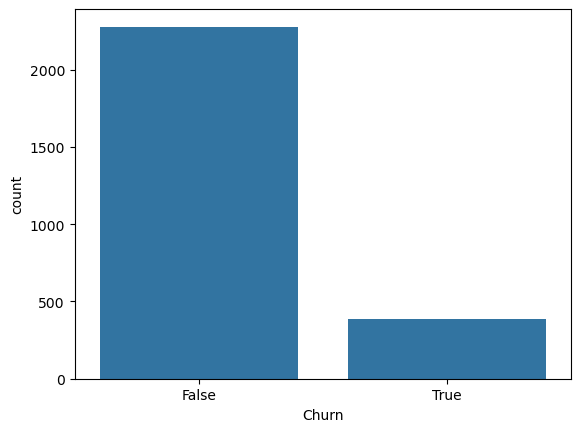

In [26]:
#타겟 변수(Churn) 불균형 비율 계산

df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)*100

sns.countplot(x='Churn', data=df)
plt.show

### 이변량 분석 (Bivariate Analysis)

- 수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
- 범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교
- 통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인
- 핵심 인사이트 도출: "고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상" 등

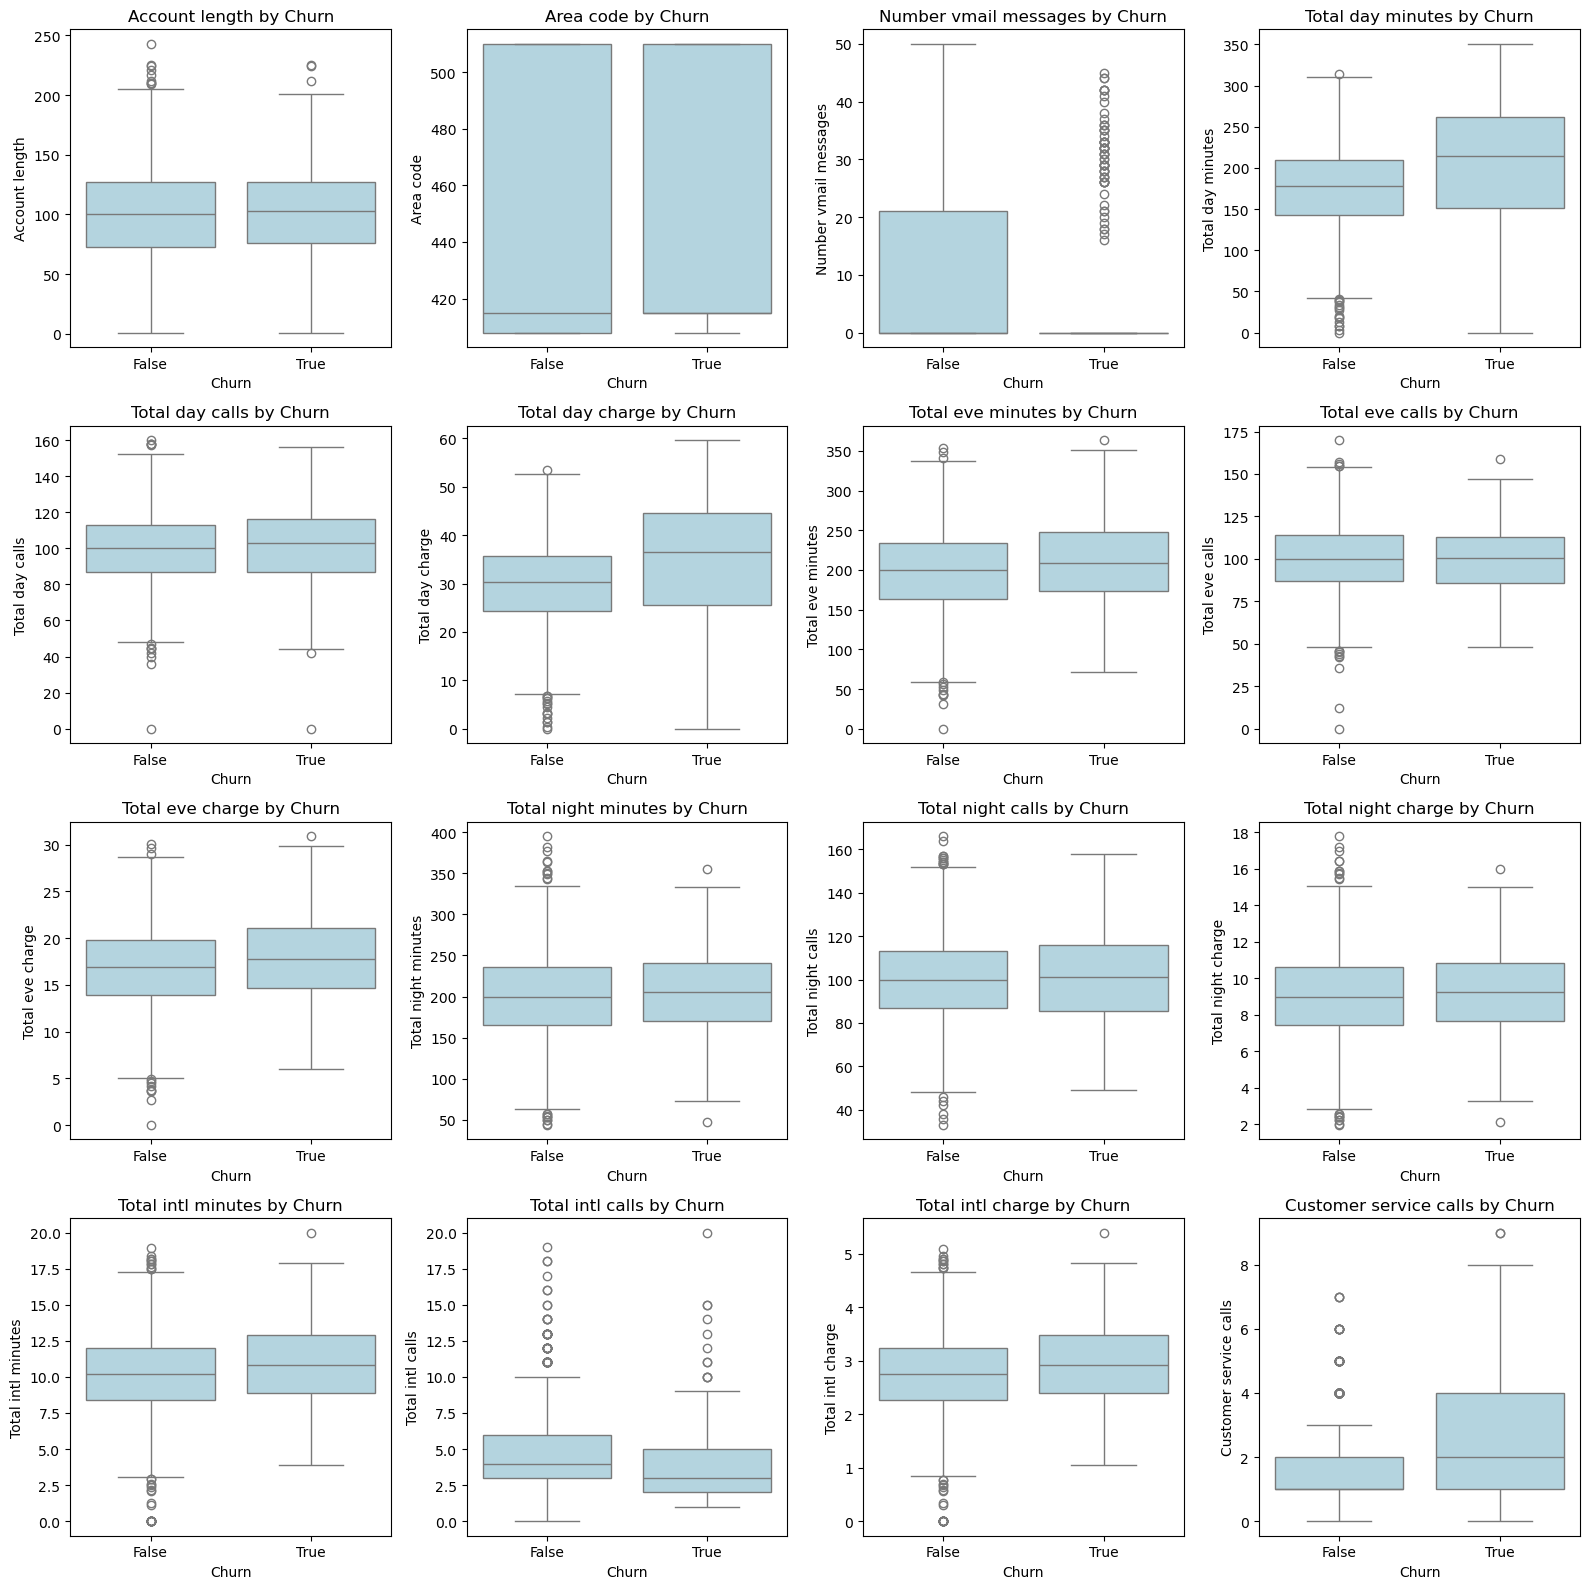

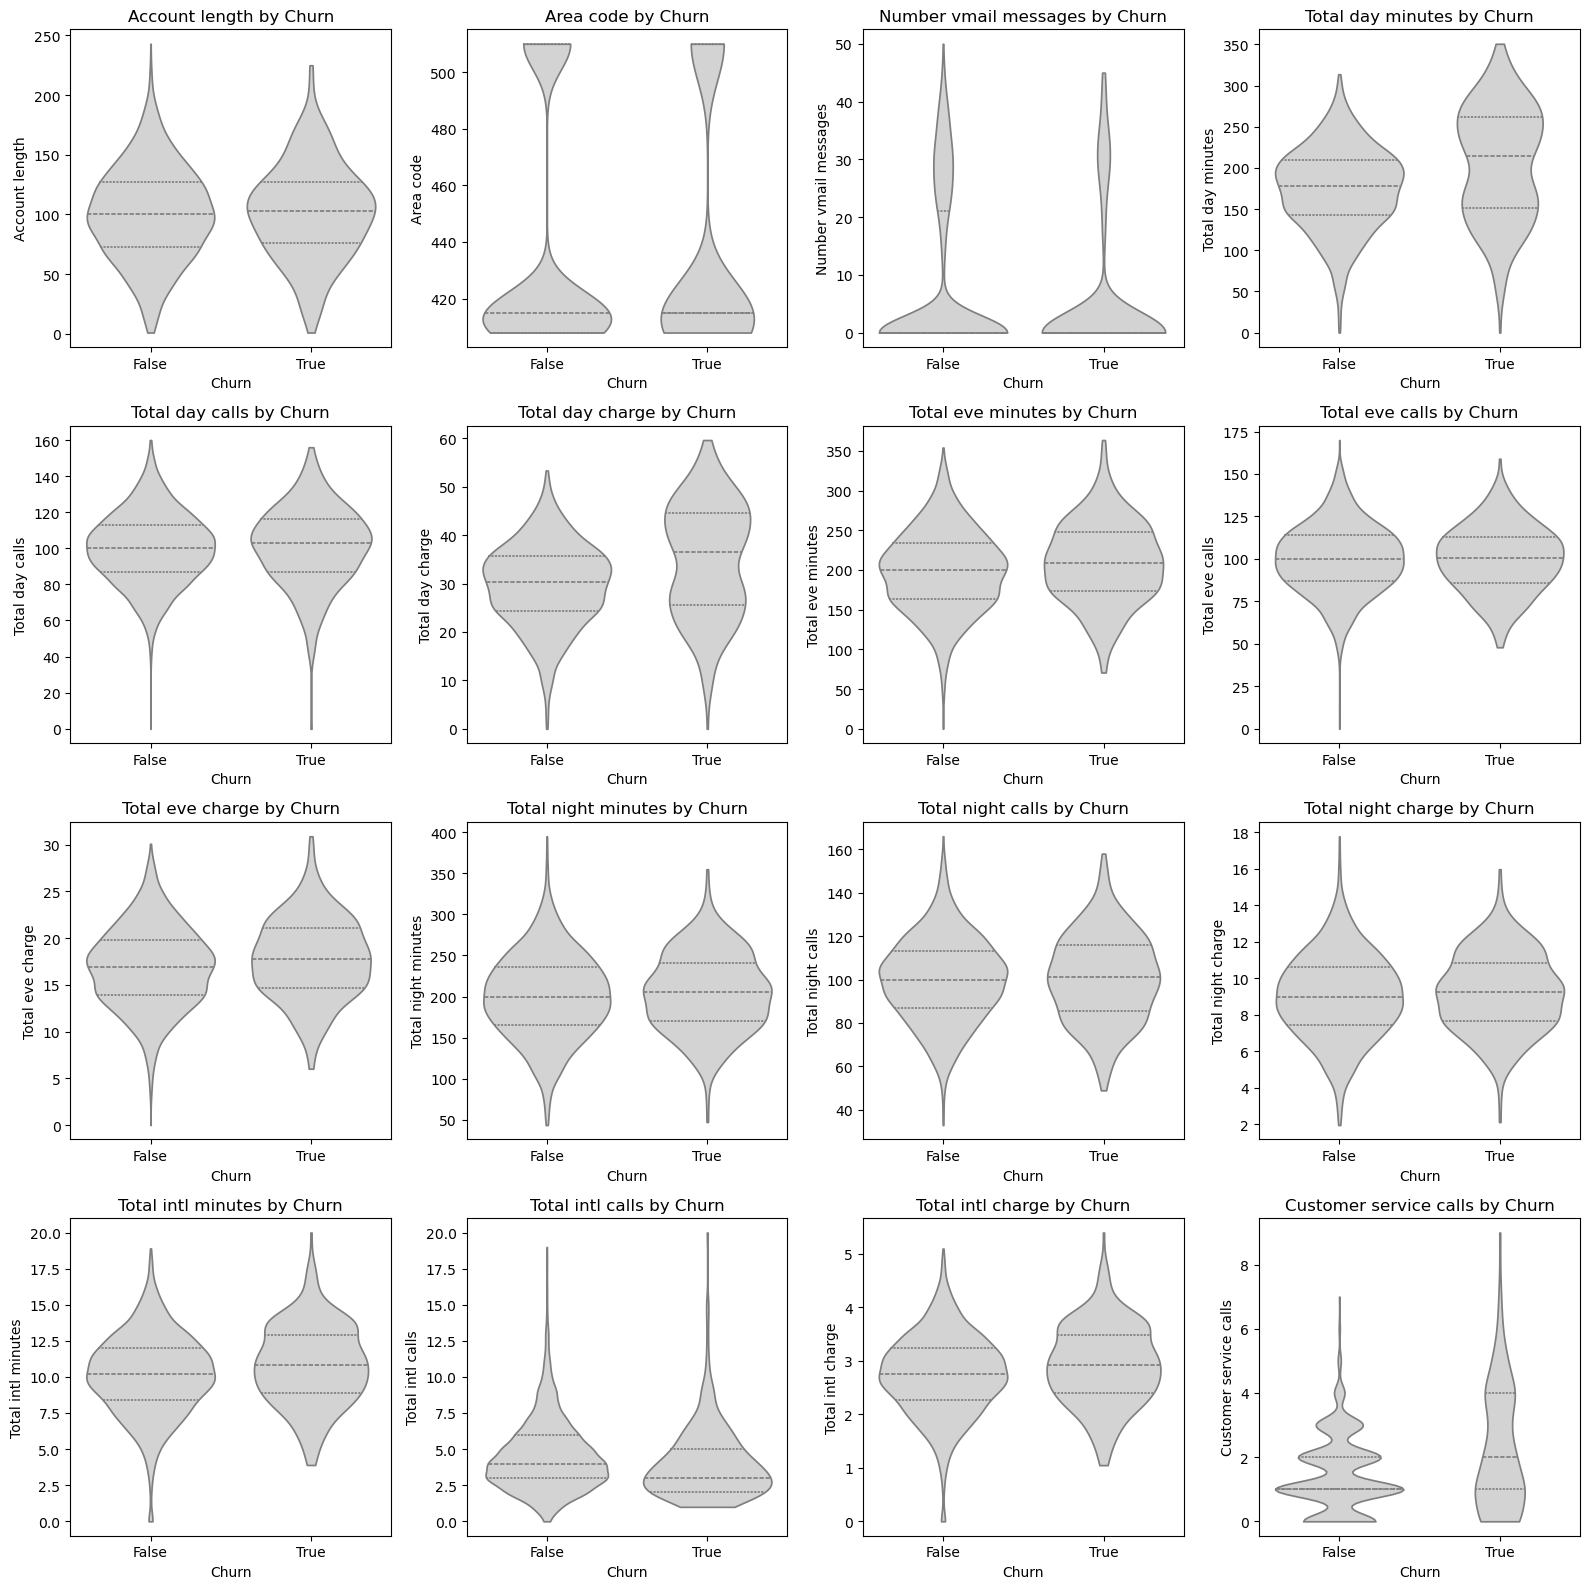

In [27]:
#수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
#박스플롯
fig, axes = plt.subplots(4,4, figsize=(16,16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x='Churn',
        y=col,
        data=df,
        ax=axes[i],
        color = 'lightblue'

    )
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')

plt.tight_layout()
plt.show()


#바이올린 플롯
fig, axes = plt.subplots(4,4, figsize=(16,16))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.violinplot(
        x='Churn',
        y=col,
        data=df,
        ax=axes[i],
        inner='quartile',   # 사분위수 표시
        cut=0,               # 범위 밖 꼬리 제거
        color='lightgrey'
    )
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')


plt.tight_layout()
plt.show()


이변량 변수 분석을 진행해본 결과 가장 눈에 띄는 것은

1) 고객 서비스 통화량(Customer service calls)
박스플롯에서
고객이 이탈한 경우(churn=true) 일때, 중앙값 범위가 눈에 띄게 넓고 false일때보다 더 위쪽에 위치해있습니다. 가장 큰 이상치도 true에 위치해 있습니다.

2) 주간 통화시간(Total day minutes) / 주간 통화 요금(Total day charge) (2개의 변수에 대해 박스플롯, 바이올린플롯 모두 비슷함)
박스플롯에서
고객이 이탈한 경우(churn=true) 일때, 동일하게 중앙값이 false일 때보다 크고 위에 위치해있음

3) 음성사서함 메세지 수(number vmail messages)
박스플롯에서 고객이 이탈한 경우 메세지 수가 거의 0. 고객이 이탈하지 않은 경우 메세지가 있는 경우가 많음

4) 국제전화 통화 횟수 (Total intl calls)
박스플롯에서
고객이 이탈한 경우 일대, 중앙값이 더 아래쪽에 위치해있음. day/eve/night의 경우 calls는 중앙값이 비슷했는데
국제전화에서는 다른 경향을 보임


-> 이를 통해 이와 관련된 변수들이 유의미하다고 판단함
number vmail messages
total day minutes
tdtal day calls
total day charge
total intl minutes
total intl charge
total intl calls
customer serivce calls


반대로
저녁 (Total eve minutes)/calls/charge
야간 (Total night minutes)/calls/charge
관련 변수들은 크게 의미가 없다고 생각되어서 제외해도 될 것이라 생각함.
다만, 다변량 분석까지 다하고 최종 결정하기로 팀원들과 이야기함




State 교차표(Crosstab)

[Crosstab]
Churn  False  True 
State              
AK        40      3
AL        59      7
AR        36     11
AZ        42      3
CA        19      5
CO        52      7
CT        48     11
DC        40      5
DE        43      8
FL        47      7
GA        41      8
HI        42      2
IA        35      3
ID        51      5
IL        41      4
IN        48      6
KS        42     10
KY        37      6
LA        32      3
MA        44      8
MD        46     14
ME        38     11
MI        45     13
MN        57     13
MO        46      5
MS        37     11
MT        43     10
NC        47      9
ND        40      4
NE        41      4
NH        34      9
NJ        36     14
NM        40      4
NV        48     13
NY        56     12
OH        56     10
OK        45      7
OR        55      7
PA        28      8
RI        45      3
SC        38     11
SD        43      6
TN        36      5
TX        39     16
UT        52      8
VA        63      4
VT      

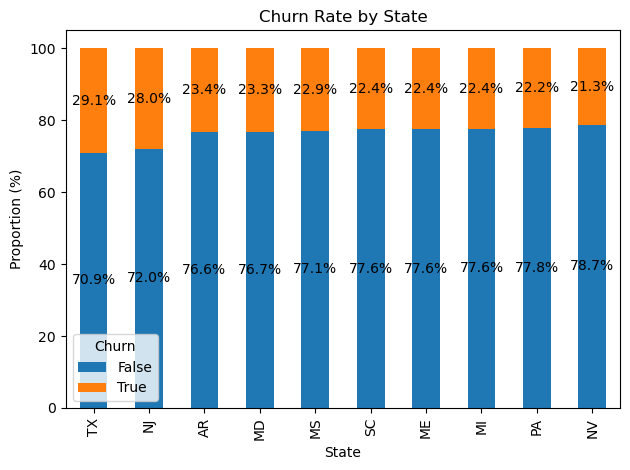

International plan 교차표(Crosstab)

[Crosstab]
Churn               False  True 
International plan              
No                   2126    270
Yes                   152    118
이탈률 : Churn                   False      True 
International plan                      
No                  88.731219  11.268781
Yes                 56.296296  43.703704


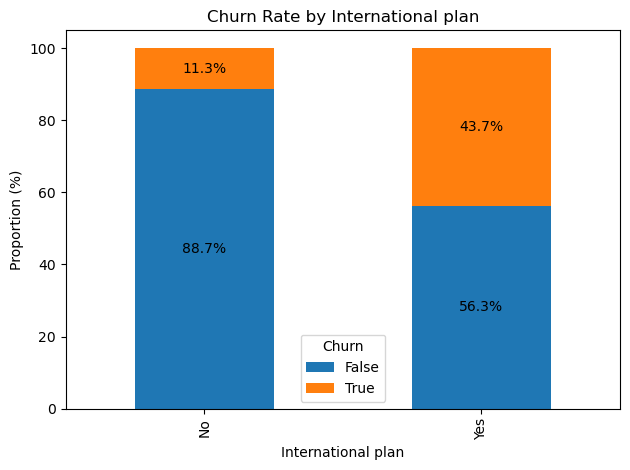

Voice mail plan 교차표(Crosstab)

[Crosstab]
Churn            False  True 
Voice mail plan              
No                1610    323
Yes                668     65
이탈률 : Churn                False      True 
Voice mail plan                      
No               83.290222  16.709778
Yes              91.132333   8.867667


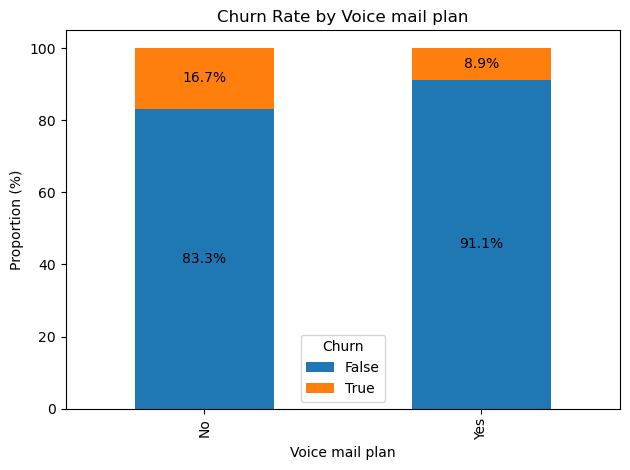

In [28]:

#범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교

for col in notnum_cols:


    #위에서 만든 notnum_cols에 churn가 포함되어있어서 churn은 넘어가도록
    if col == 'Churn':
        continue
    #교차표(Crosstab)
    print(f"{col} 교차표(Crosstab)")
    crosstab_count = pd.crosstab(df[col], df['Churn'])
    print('\n[Crosstab]')
    print(crosstab_count)

    #이탈률
    crosstab_rate = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    ) * 100

    print(f"이탈률 : {crosstab_rate}")

    plot_data = crosstab_rate.copy()

    #State는 값이 너무 다양해서 상위 10개만
    if col == 'State':
        plot_data = plot_data.sort_values(by=True, ascending=False).head(10)

    #스택 바 차트
    ax = plot_data.plot(
        kind='bar',
        stacked=True
    )

    #막대 안에 % 나오도록 표시
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%',
            label_type='center'
    )

    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Proportion (%)')
    plt.xlabel(col)
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()

1) International plan
국제전화 요금제 가입 여부에서 가장 큰 차이가 보임
국제전화 요금제를 가입한 사람들의 고객 이탈률이 43.7%
가입하지 않은 사람들은 11.3%

국제전화 요금제를 가입한 사람들이 이탈하는 경향이 크게 보임

2) Voice mail plan
음성사서함 요금제 가입 여부에서 차이가 보임
음성사서함 요금제 가입을 안한 사람들의 고객 이탈률이 그렇지 않은 사람들의 약 2배

음성사서함 요금제 가입을 한 사람들이 이탈하지 않는 경향이 보임

3) State
주 (지역)에 따른 이탈률은 큰 차이가 없어보임
데이터 범주가 넓어서 상위 10개만 했는데, 상위 5개 & 하위 5개로 해보면 다를 수 도 있겠다는 생각이 듦



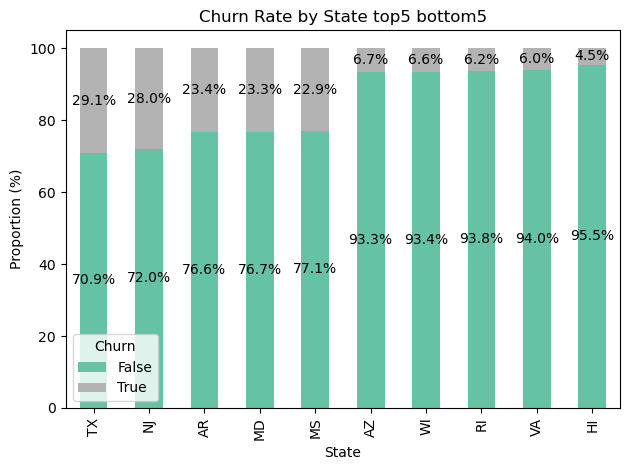

In [29]:
#이탈률
crosstab_rate = pd.crosstab(
                        df['State'],
                        df['Churn'],
                        normalize='index'
                    ) * 100

plot_data = crosstab_rate.copy()

#State는 값 상위 5개, 하위 5개
top5 = plot_data.sort_values(by=True, ascending=False).head(5)
bottom5 = plot_data.sort_values(by=True, ascending=False).tail(5)

total = pd.concat([top5,bottom5])

#스택 바 차트
ax = total.plot(
        kind='bar',
        stacked=True,
        colormap = 'Set2'
    )

#막대 안에 % 나오도록 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.title(f'Churn Rate by State top5 bottom5')
plt.ylabel('Proportion (%)')
plt.xlabel('State')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

In [30]:
print('Top5 Bottom5 State 고객 수')
print(df['State'].value_counts().loc[total.index])

Top5 Bottom5 State 고객 수
State
TX    55
NJ    50
AR    47
MD    60
MS    48
AZ    45
WI    61
RI    48
VA    67
HI    44
Name: count, dtype: int64


주(지역)별 이탈률 top 5와 bottom 5를 비교해봄
상위 5개 지역과 하위 5개 지역의 이타률 차이 약 3~4배

이때, 해당 주에 고객수가 너무 적으면 이탈률이 높거나 적더라도 의미가 없을 것 같아서
지역 별 고객수를 확인해보았고, 고객수는 지역 별로 비슷함

In [31]:
#통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인

# notnum_cols = df.select_dtypes(exclude=['int64','float64']).columns
# 위에서 범주형 변수를 따로 만들때, churn을 포함해서 만들어서 번거로운 경우가 생겨서 churn 제외한 범주형 변수리스트 다시 만듬

notnum_cols = [col for col in notnum_cols if col != 'Churn']
notnum_cols

['State', 'International plan', 'Voice mail plan']

In [32]:
#범주형 변수에 대해 카이 제곱 검정을 수행함
from scipy.stats import chi2_contingency

results = []

for col in notnum_cols:
    #교차표
    ct = pd.crosstab(df[col], df['Churn'])

    #카이제곱 검정
    chi2, p_value, dof, expected = chi2_contingency(ct)


    results.append({
        'Variable': col,
        'Chi_square': chi2,
        'P_value': p_value,
        'Degrees_of_freedom': dof
    })

# 4. 결과를 DataFrame으로 정리
chi_square_results = pd.DataFrame(results).sort_values(by='P_value')
chi_square_results

,Variable,Chi_square,P_value,Degrees_of_freedom
1,International plan,202.682107,5.426941e-46,1
2,Voice mail plan,25.656253,4.079713e-07,1
0,State,79.798593,4.680702e-03,50


범주형 변수 3개 모두 p_value가 0.05 이하로 통계적으로 유의하므로
churn 변수와 관계가 있을 가능성이 높다

다만, State의 경우 p-value는 0.05 이하이면서 자유도가 50
카이 검정 제곱에서는 표본 수가 충분히 크면 범주 수가 많을 때 작은 차이가 누적되서 통계적으로 유의하게 나올 수 있기때문에
모델에 적용할 때, 주의해서 사용해야함



In [33]:
# 위에서 state top5 , bottom5 이탈률 구했던 것을 사용해서 범주 수를 10개로 줄여서 다시 한번 카이검정제곱을 적용해봄
# total = pd.concat([top5,bottom5])

state_result=[]
selected_states = list(top5.index) + list(bottom5.index)
df_state_10 = df[df['State'].isin(selected_states)]

ct_state_10 = pd.crosstab(df_state_10['State'], df_state_10['Churn'])

chi2, p_value, dof, expected = chi2_contingency(ct_state_10)


state_result.append({
        'Variable': 'State',
        'Chi_square': chi2,
        'P_value': p_value,
        'Degrees_of_freedom': dof
    })

chi_square_results = pd.DataFrame(state_result)
chi_square_results

,Variable,Chi_square,P_value,Degrees_of_freedom
0,State,38.760228,0.000013,9


전체 state를 대상으로 카이제곱검정을 진행했을 때, 통계적으로 유의함을 확인하였고
top5, bottom5 state 대상으로 카이제곱검정을 재진행한 결과값에서도 p-vaule = 0.000013으로 통계적으로 유의함을 확인하였다.

일부 지역에서 이탈률 차이가 나타나는 것이 확인됨

In [34]:
#연속형 변수에 대해 t-test를 수행함

from scipy.stats import ttest_ind
num_cols_new = [
    'Number vmail messages',
    'Total day minutes',
    'Total day calls',
    'Total day charge',
    'Total intl minutes',
    'Total intl charge',
    'Total intl calls',
    'Customer service calls'
]


results = []

for col in num_cols_new:
    churn_true = df[df['Churn'] == True][col]
    churn_false = df[df['Churn'] == False][col]

    # Welch's t-test
    # churn 여부에 따라 두 집단의 분산이 다를 가능성이 높아서 등분산 가정을 하지 않는 welch's t-test를 사용함

    t_stat, p_value = ttest_ind(
        churn_true,
        churn_false,
        equal_var=False
    )

    results.append({
        'Variable': col,
        'Mean_Churn_True': churn_true.mean(),
        'Mean_Churn_False': churn_false.mean(),
        'Mean_Diff (True - False)': churn_true.mean() - churn_false.mean(),
        'T_statistic': t_stat,
        'P_value': p_value
    })


ttest_results = pd.DataFrame(results).sort_values(by='P_value')
ttest_results

,Variable,Mean_Churn_True,Mean_Churn_False,Mean_Diff (True - False),T_statistic,P_value
1,Total day minutes,205.181186,175.104346,30.076840,8.280870,1.341688e-15
3,Total day charge,34.881340,29.768266,5.113074,8.280801,1.342382e-15
7,Customer service calls,2.206186,1.453029,0.753157,7.640624,1.376831e-13
0,Number vmail messages,5.170103,8.507463,-3.337360,-4.988924,8.031679e-07
5,Total intl charge,2.921727,2.737709,0.184018,4.475092,9.360700e-06
4,Total intl minutes,10.819330,10.137840,0.681490,4.474848,9.370908e-06
6,Total intl calls,4.051546,4.538191,-0.486645,-3.593477,3.570233e-04
2,Total day calls,101.195876,100.159350,1.036526,0.880986,3.787478e-01


total day calls을 제외한 모든 변수는 p-value가 0.05보다 작기때문에 통계적으로 유의함을 알 수 있음
total day calls는 통계적으로 유의하지 않음

1) Total day minutes (or charge)

이탈 고객은 낮 시간 통화 사용량이 유의하게 높음을 알 수 있다.
과도한 사용에 따른 요금 부담이 이탈로 이어질 가능성을 보여준다.

2) Customer service calls

이탈 고객은 비이탈 고객보다 고객센터 문의 횟수가 평균적으로 유의하게 많음
이는 서비스 불만이 이탈 가능성을 높인다고 볼 수 있다.

3) Number vmail messages

비이탈 고객은 음성메일 메시지 수가 유의하게 많다.
음성사서함 서비스 이용도가 고객 유지에 긍정적인 역할을 할 수 있음을 보여준다.

4) Total intl minutes / charge

이탈 고객은 국제 통화 사용량 및 요금이 유의하게 높음.
국제 서비스 이용 부담이 이탈 요인으로 작용할 가능성이 있다.

5) Total intl calls

비이탈 고객이 국제 통화를 더 자주 하지만, 이탈 고객은 통화당 사용 시간이 더 긴 패턴을 보임.

**핵심 인사이트 도출**

고객 이탈은 요금, 국제전화 서비스 이용, 고객 센터 문의 경험과 연관되어 있다.
반면에 음성사서함 이용 고객은 상대적으로 이탈률이 낮다.

### 다변량 분석 (Multivariate Analysis)

- 상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화
- 다중공선성 확인 (주간/야간 통화시간-요금 간 높은 상관관계 등)
- Pair plot으로 변수 간 관계 시각화
- PCA를 통한 차원 축소 및 주요 성분 해석 (선택적)

In [35]:
df['Churn_bin'] = df['Churn'].map({False: 0, True: 1})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [36]:
#상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화

selected_cols = [
    'Number vmail messages',
    'Total day minutes',
    'Total day calls',
    'Total day charge',
    'Total intl minutes',
    'Total intl charge',
    'Total intl calls',
    'Customer service calls',
    'International_plan_bin',
    'Voice_mail_plan_bin',
    'Churn_bin'
]

df_corr = df[selected_cols]
corr_matrix = df_corr.corr()

corr_matrix

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total intl minutes,Total intl charge,Total intl calls,Customer service calls,International_plan_bin,Voice_mail_plan_bin,Churn_bin
Number vmail messages,1.000000,0.019027,-0.009622,0.019027,-0.004156,-0.004136,0.027013,-0.018787,0.005858,0.957159,-0.086474
Total day minutes,0.019027,1.000000,0.016780,1.000000,-0.011042,-0.010934,0.005687,-0.024543,0.049550,0.013438,0.195688
Total day calls,-0.009622,0.016780,1.000000,0.016787,0.031036,0.031133,0.006928,-0.011945,-0.004277,-0.007541,0.018290
Total day charge,0.019027,1.000000,0.016787,1.000000,-0.011046,-0.010938,0.005688,-0.024548,0.049555,0.013439,0.195689
Total intl minutes,-0.004156,-0.011042,0.031036,-0.011046,1.000000,0.999993,0.037315,-0.002826,0.053162,-0.013963,0.086204
Total intl charge,-0.004136,-0.010934,0.031133,-0.010938,0.999993,1.000000,0.037363,-0.002895,0.053037,-0.013931,0.086216
Total intl calls,0.027013,0.005687,0.006928,0.005688,0.037315,0.037363,1.000000,-0.022143,0.011549,0.015196,-0.069882
Customer service calls,-0.018787,-0.024543,-0.011945,-0.024548,-0.002826,-0.002895,-0.022143,1.000000,-0.035955,-0.022054,0.202590
International_plan_bin,0.005858,0.049550,-0.004277,0.049555,0.053162,0.053037,0.011549,-0.035955,1.000000,0.002131,0.277489
Voice_mail_plan_bin,0.957159,0.013438,-0.007541,0.013439,-0.013963,-0.013931,0.015196,-0.022054,0.002131,1.000000,-0.099291


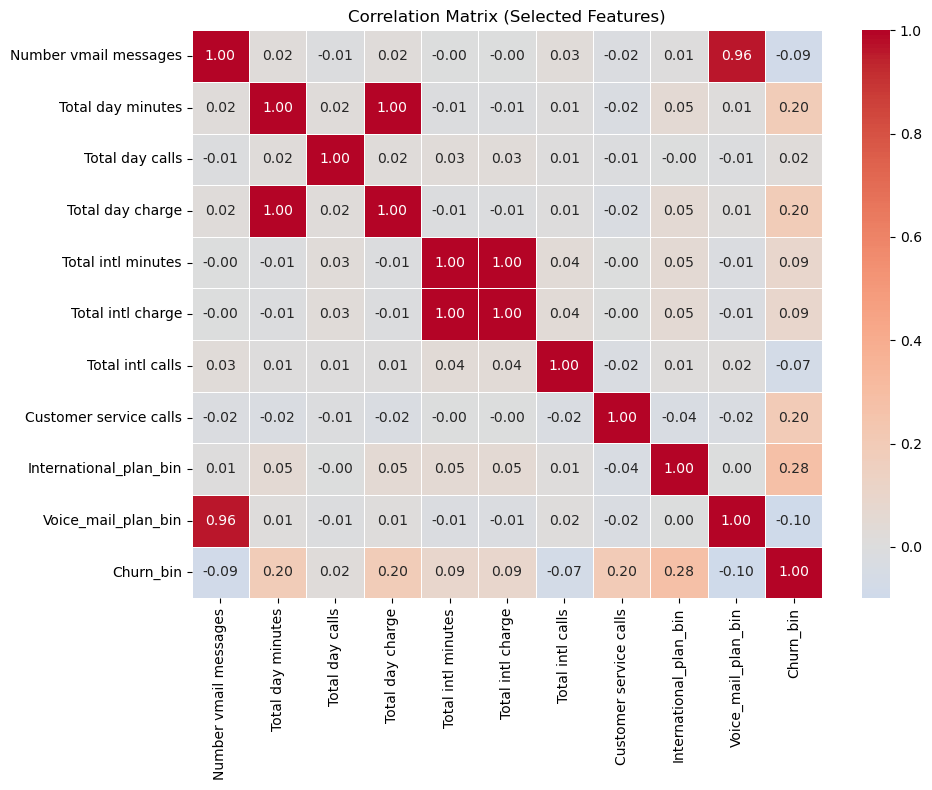

In [37]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # 상관계수 숫자 표시
    fmt=".2f",           # 소수점 2자리
    cmap='coolwarm',     # 색상
    center=0,            # 0 기준 색상 분리
    linewidths=0.5
)

plt.title('Correlation Matrix (Selected Features)')
plt.tight_layout()
plt.show()

Churn(Churn_bin)과의 상관관계를 살펴보면
1) International_plan_bin : 0.28
가장 높은 상관계수, 국제 요금제 사용 고객일수록 이탈 가능성 높다고 판단됨

2) Total day minutes / Total day charge : 0.20
낮 사용량/요금이 높을수록 이탈 가능성 높다고 판단됨

3) Customer service calls : 0.20
고객센터 문의 횟수가 높을수록 이탈 가능성 높다고 판단됨

4) Total intl minutes / Total intl charge : 0.09
약한 상관관계를 보임

5) Voice_mail_plan_bin : -0.10
음의 상관관계를 보임
음성사서함 요금제를 사용할수록 이탈 가능성 적음

6) Number vmail messages : -0.09
음의 상관관계를 보임
음성사서함 요금제 사용 여부와 같이 보면 좋을 것 같음
음성사서함 메세지가 많을수록 이탈 가능성 적음

7) Total intl calls : 0.07
상관관계가 낮은 편

8) Total day calls : 0.02
상관관계가 가장 낮음



**강한 상관 관계**
Total day charge - Total day minutes (1)
Total intl charge - Total intl minutes (1)
Voice_mail_plan_bin - Number vmail messages (0.96)

다중공선성 확인

위의 상관관계 히트맵을 통해서

Total day charge - Total day minutes : 1
Total intl charge - Total intl minutes : 1
Voice_mail_plan_bin - Number vmail messages : 0.96

세쌍의 값이 강한 상관관계가 있음을 알 수 있습니다.


이를 통해 각각의 쌍에서 하나를 제거하는게 좋을 것 같다고 판단함
1)  요금(charge)과 사용시간(minutes) 중에서 사용시간으로 인해 요금이 측정된다고 생각하여
요금을 제거하기로 결정함

2) 음성사서함 가입 여부와 음성사서함 메세지 수 중에서 음성사서함을 가입해야 메세지수가 생기기때문에 메세지 수를 제거하기로 결정함


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

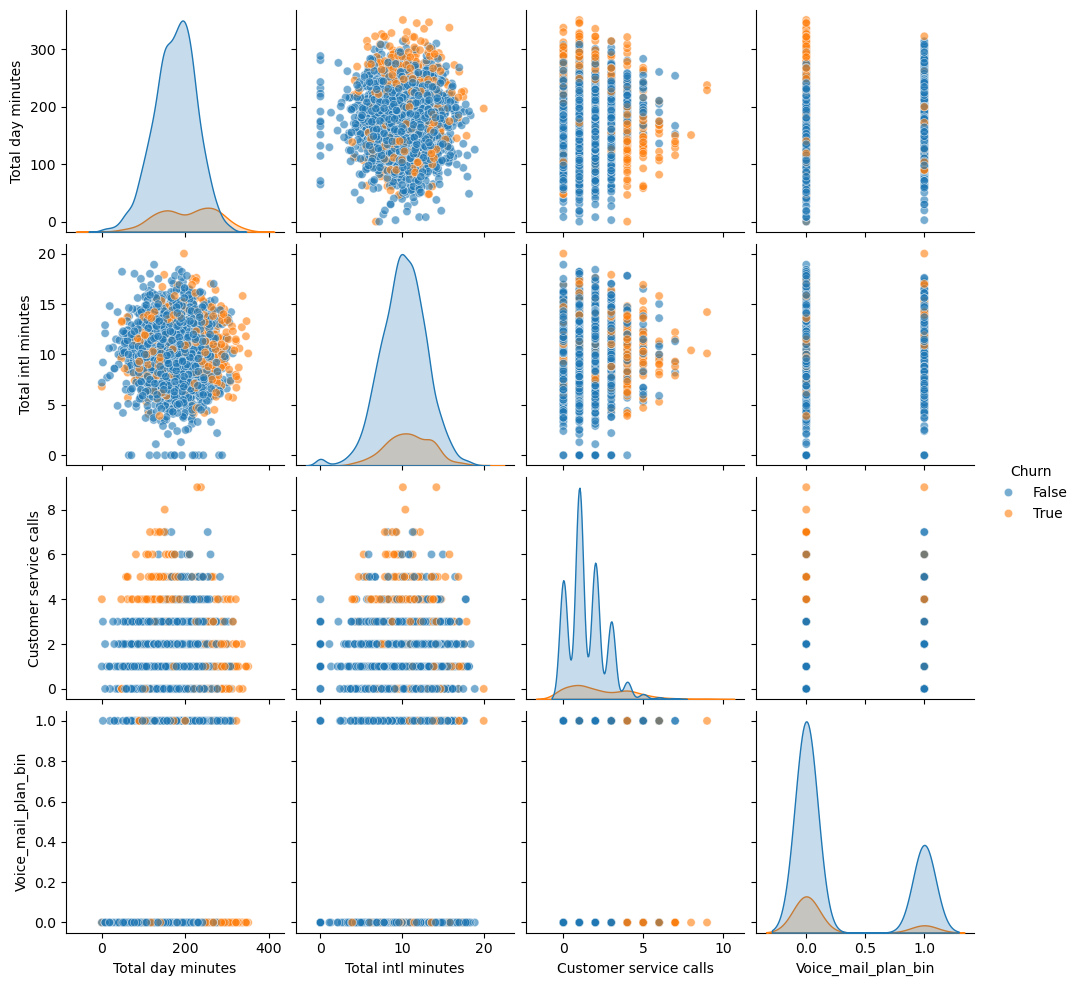

In [39]:
#Pair plot으로 변수 간 관계 시각화

pair_cols = [
    'Total day minutes',
    'Total intl minutes',
    'Customer service calls',
    'Voice_mail_plan_bin',
    'Churn'
]

sns.pairplot(
    df[pair_cols],
    hue='Churn',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

1) Customer service calls, Voice_mail_plan_bin
-> 고객센터 문의 많으면서 음성사서함 요금제 사용안하면 이탈 가능성 높음

2) Total day minutes, Voice_mail_plan_bin
-> 주간 통화시간이 많으면서 음성사서함 요금제 사용안하면 이탈 가능성 높음

In [40]:
#PCA를 통한 차원 축소 및 주요 성분 해석

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pca_cols = [
    'Total day minutes',
    'Total intl minutes',
    'Customer service calls',
    'Voice_mail_plan_bin'
]


# 1. 데이터 선택
X = df[pca_cols]

# 2. 표준화 (PCA는 반드시 필요)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA 수행
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. 설명 분산 비율
explained_var = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca_cols))],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': pca.explained_variance_ratio_.cumsum()
})

explained_var

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.260947,0.260947
1,PC2,0.250702,0.511649
2,PC3,0.246533,0.758181
3,PC4,0.241819,1.000000


모든 PC가 24~26%로 매우 균등

->

변수들 간 상관은 있지만 매우 강하지 않음

한 개의 **지배적인 패턴**이 없음

고객 이탈이 단일 요인이 아닌 복합적 행동 결과

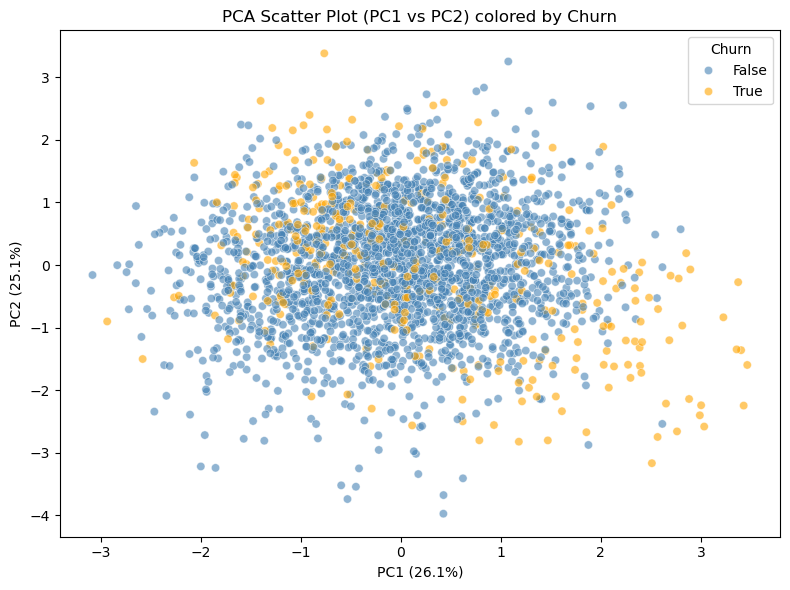

In [41]:


# PCA (PC1, PC2만 사용)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PCA 결과를 DataFrame으로 변환
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Churn'] = df['Churn'].values  # True / False 그대로 사용

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Churn',
    palette={False: 'steelblue', True: 'orange'},
    alpha=0.6
)

plt.title('PCA Scatter Plot (PC1 vs PC2) colored by Churn')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

pca는 어려워서 중도 포기..

**비즈니스 인사이트 도출**

- 이탈 고객의 주요 특징 3-5가지 정리

1) 고객센터 문의 횟수 많음

Churn=True 평균: 2.2회
Churn=False 평균: 1.45회

t-test 결과: p < 0.001

-> 불만이 누적된 고객일수록 이탈 가능성 높음

2) 국제전화 요금제 사용함

International plan = Yes → 이탈률 44%
International plan = No → 이탈률 11%

Chi-square 결과:

-> 요금 부담으로 인해 이탈 가능성 급증

3) 주간 통화시간 / 요금이 높음

Total day minutes / charge: Churn=True가 유의하게 더 높음

t-test 결과: p < 0.001

-> 주간 통화량/요금이 많은 고객이 이탈 가능성 높음

4) 음성 사서함(Voice mail plan) 가입자는 이탈률 낮음

Voice mail plan = Yes → 이탈률 9%
Voice mail plan = No → 이탈률 17%

Chi-square: p < 0.001

-> 서비스 락인 효과로 해당 서비스를 이용하면 이탈률이 낮다

- 지역별/요금제별 이탈률 차이 분석
State별 이탈률: 약 21% ~ 29% 범위

상위 5 / 하위 5로 나누었을 때 이탈률 : Chi-square test → 통계적으로 유의

요금제 별 이탈률
1) International plan
이탈률 차이 가장 큼

2) Voice mail plan
가입한 고객들 이탈률이 적음


- 고위험 고객 프로필 정의
1) International plan = Yes
2) Customer service calls >= 2
3) International plan = Yes
4) Voice mail plan = No
5) Total day minutes / Total intl minutes 높음

- EDA 결과를 바탕으로 가설 수립


가설1) 고객센터 문의 횟수는 이탈 가능성이 높다

가설2) 국제전화 요금제를 사용하는 고객은 요금 부담때문에 이탈 가능성이 높다

가설3) 음성사서함 요금제는 고객 락인 효과로 인하여 이탈률을 낮춘다

가설4) 통화를 많이 할수록 요금 부담때문에 이탈 가능성이 높다

------------------
여기서부터 JoSooKyung

확인된 부분   
1. International plan을 사용하는 고객의 이탈률은 43.7%로 매우 높다.

2. Customer service calls 횟수가 많을수록 이탈률이 증가한다.

3. Voice mail plan을 사용하지 않으면서 고객센터 문의가 잦은 고객의 이탈률이 특히 높다.

4. State별 이탈률을 비교했을 때, 상위 5개 주와 하위 5개 주의 이탈률 차이는 약 3~4배에 달한다.

---



* International_plan_bin
→ 이탈과 가장 강한 관계 (이탈률 ~43.7%, 상관계수 ~0.28)

* Customer service calls
→ 이탈 고객에서 평균적으로 높음

* Voice_mail_plan_bin
→ 고객센터 호출과 결합 시 이탈 위험 증가

개인 사용 행태·요금·서비스 경험이 이탈과 연관됨은 이미 확인

고위험 지역 Top 10
State	Churn Rate	State Full Name   
43	TX	0.290909	Texas   
31	NJ	0.280000	New Jersey   
2	AR	0.234043	Arkansas   
20	MD	0.233333	Maryland   
25	MS	0.229167	Mississippi   
40	SC	0.224490	South Carolina   
21	ME	0.224490	Maine    
22	MI	0.224138	Michigan   
38	PA	0.222222	Pennsylvania    
33	NV	0.213115	Nevada   

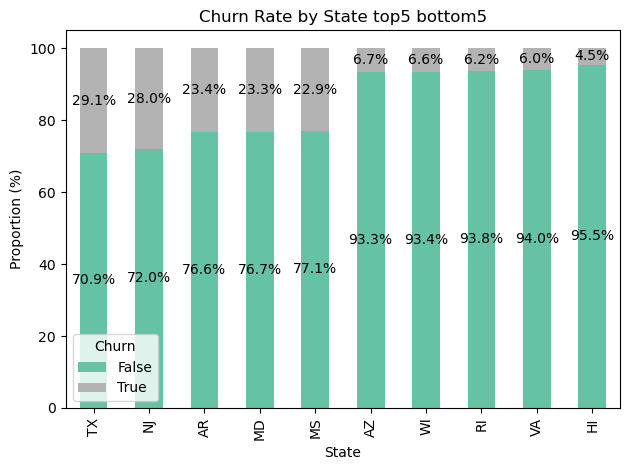

Top5 Bottom5 State 고객 수
State
TX    55
NJ    50
AR    47
MD    60
MS    48
AZ    45
WI    61
RI    48
VA    67
HI    44
Name: count, dtype: int64


In [42]:
# “주(지역)별 이탈률 top5와 bottom5의 차이가 약 3~4배”
# 이 지역 차이는
# 1. 개인 요금제/사용행태 차이 때문일까,
# 2. 아니면 지역 환경 자체의 영향일까?

#이탈률
crosstab_rate = pd.crosstab(
                        df['State'],
                        df['Churn'],
                        normalize='index'
                    ) * 100

plot_data = crosstab_rate.copy()

#State는 값 상위 5개, 하위 5개
top5 = plot_data.sort_values(by=True, ascending=False).head(5)
bottom5 = plot_data.sort_values(by=True, ascending=False).tail(5)

total = pd.concat([top5,bottom5])

#스택 바 차트
ax = total.plot(
        kind='bar',
        stacked=True,
        colormap = 'Set2'
    )

#막대 안에 % 나오도록 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center'
    )

plt.title(f'Churn Rate by State top5 bottom5')
plt.ylabel('Proportion (%)')
plt.xlabel('State')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print('Top5 Bottom5 State 고객 수')
print(df['State'].value_counts().loc[total.index])

국제 요금제를 사용하고,   
고객센터에 여러 번 문의하고,   
음성사서함 요금제를 사용하지 않는 고객이라 하더라도,   
어느 주(State)에 속해 있는지에 따라 이탈률이 달라질까?  

가설 1   
국제 요금제 사용 여부, 고객센터 문의 횟수, 음성사서함 요금제 여부가 동일하더라도,   
고객이 속한 주(State)에 따라 이탈률은 다르게 나타날 것이다.   

먼저,지역을 Low / Mid / High risk로 나눈 뒤   
리스크 그룹별 이탈률이 단계적으로 증가하는 패턴을 확인해보자

*Low risk	State 평균 이탈률 < 10%   
*Mid risk	10% ≤ State 평균 이탈률 < 20%   
*High risk	State 평균 이탈률 ≥ 20%   

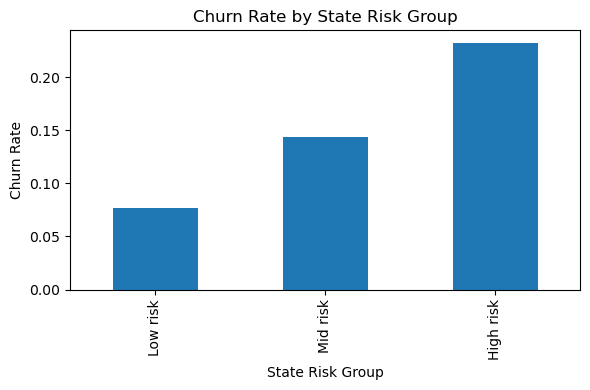

state_risk_group
Low risk     0.076923
Mid risk     0.143302
High risk    0.232484
Name: Churn_bin, dtype: float64

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Churn 변수 이진화 (노트북 기준)
if df['Churn'].dtype == bool:
    df['Churn_bin'] = df['Churn'].astype(int)
else:
    df['Churn_bin'] = df['Churn'].astype(str).str.lower().map({'true': 1, 'false': 0})

# 2. State별 이탈률 계산
state_churn_rate = df.groupby('State')['Churn_bin'].mean()

# 3. 리스크 그룹 정의
def risk_group(rate):
    if rate >= 0.20:
        return 'High risk'
    elif rate >= 0.10:
        return 'Mid risk'
    else:
        return 'Low risk'

state_risk_map = state_churn_rate.apply(risk_group)

# 4. 고객 데이터에 리스크 그룹 매핑
df['state_risk_group'] = df['State'].map(state_risk_map)

# 5. 리스크 그룹별 평균 이탈률 계산
risk_group_churn = (
    df.groupby('state_risk_group')['Churn_bin']
      .mean()
      .reindex(['Low risk', 'Mid risk', 'High risk'])
)

# 6. 시각화
plt.figure(figsize=(6, 4))
risk_group_churn.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.xlabel('State Risk Group')
plt.title('Churn Rate by State Risk Group')
plt.tight_layout()
plt.show()

# 확인용 출력
risk_group_churn


In [44]:
# Low / Mid / High risk 지역에서
# 국제 요금제 사용, 고객센터 문의, 음성사서함 요금제와 이탈률의 관계가 어떻게 보이는지

# 리스크 그룹별 이탈률 재확인
df.groupby('state_risk_group')['Churn_bin'].mean()


state_risk_group
High risk    0.232484
Low risk     0.076923
Mid risk     0.143302
Name: Churn_bin, dtype: float64

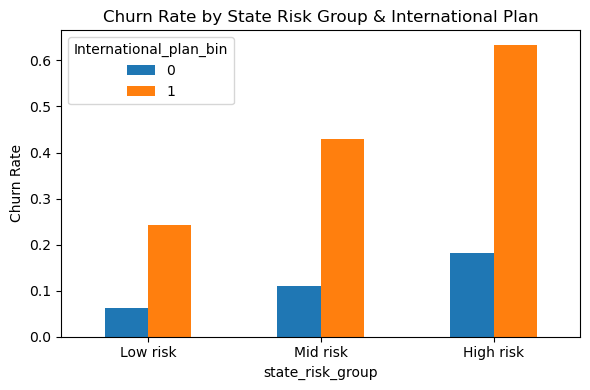

 ✅ 국제 전화요금제를 쓰든 안 쓰든,지역 리스크가 높아질수록 이탈률은 올라간다.


In [48]:
# 리스크 그룹별 국제 요금제 사용 고객의 이탈률
import matplotlib.pyplot as plt

intl_churn = (
    df.groupby(['state_risk_group', 'International_plan_bin'])['Churn_bin']
      .mean()
      .unstack()
      .reindex(['Low risk', 'Mid risk', 'High risk'])
)

intl_churn.plot(kind='bar', figsize=(6,4))
plt.ylabel('Churn Rate')
plt.title('Churn Rate by State Risk Group & International Plan')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(" ✅ 국제 전화요금제를 쓰든 안 쓰든,지역 리스크가 높아질수록 이탈률은 올라간다.")



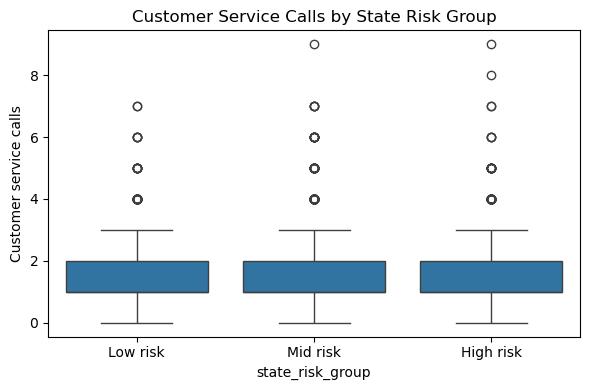

 ✅ High risk 지역일수록 고객센터 문의 횟수가 더 많으며, 이는 이탈률 증가와 연관될 수 있다.


In [ ]:
# 리스크 그룹별 고객센터 문의 횟수 분포
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x='state_risk_group',
    y='Customer service calls',
    order=['Low risk', 'Mid risk', 'High risk']
)
plt.title('Customer Service Calls by State Risk Group')
plt.tight_layout()
plt.show()
print(" ✅ High risk 지역일수록 고객센터 문의 횟수가 더 많이 관찰된다.")

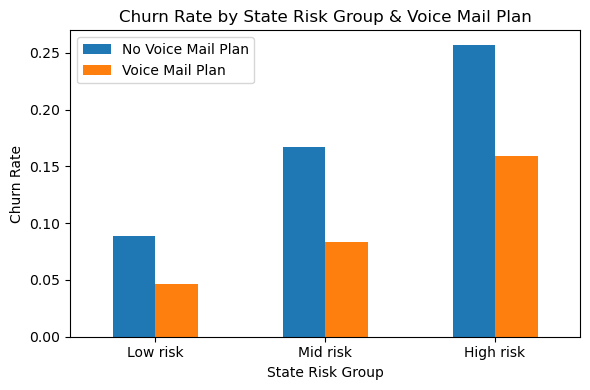

In [49]:
# 같이 음성사서함을 쓰거나 안 쓰는 고객끼리 비교했을 때도
# 지역 리스크가 높아지면 이탈률이 올라가느냐”

import matplotlib.pyplot as plt

# Voice mail plan 이진 변수 확인 (이미 있다면 생략 가능)
# Yes = 1, No = 0
if 'Voice_mail_plan_bin' not in df.columns:
    df['Voice_mail_plan_bin'] = (df['Voice mail plan'] == 'Yes').astype(int)

# 리스크 그룹 × 음성사서함 요금제별 이탈률 계산
vm_churn = (
    df.groupby(['state_risk_group', 'Voice_mail_plan_bin'])['Churn_bin']
      .mean()
      .unstack()
      .reindex(['Low risk', 'Mid risk', 'High risk'])
)

# 시각화
vm_churn.plot(kind='bar', figsize=(6,4))
plt.ylabel('Churn Rate')
plt.xlabel('State Risk Group')
plt.title('Churn Rate by State Risk Group & Voice Mail Plan')
plt.xticks(rotation=0)
plt.legend(['No Voice Mail Plan', 'Voice Mail Plan'])
plt.tight_layout()
plt.show()


지역이 바뀌면, 개별 변수들이 “따로” 움직이지 않고   
같이 묶여서 움직인다.    
“지역에 따라 이탈률이 다르다”는 사실은 맞지만,
그 이유가 ‘지역 자체’인지,
아니면 ‘그 지역에 그런 고객이 많이 모여 있어서’인지는
아직 분리되지 않았다.

지역에 따라   
이탈과 연관된 행동·요금제·경험이   
‘같은 방향으로 동시에 강화되는 구조’가 존재한다.   

고위험지역은 이탈 조건이 ‘쌓이는’ 곳이고,
저위험지역은 이탈 조건이 ‘흩어지는’ 곳이다.

/var/folders/zx/5ql37vbd32l6kwdp9gj2844m0000gn/T/ipykernel_69919/2996092780.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(day_data, labels=order)
/var/folders/zx/5ql37vbd32l6kwdp9gj2844m0000gn/T/ipykernel_69919/2996092780.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(night_data, labels=order)


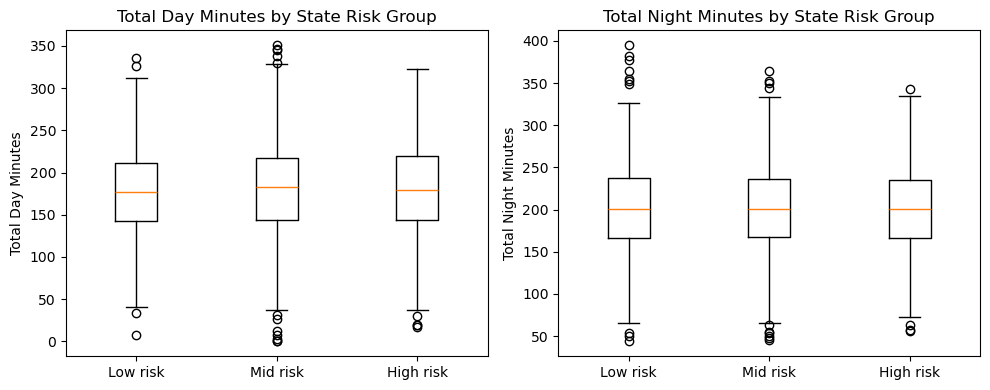

 ✅ 별차이 없음


In [53]:
#지역별 주간 야간 통화량 비교

import pandas as pd
import matplotlib.pyplot as plt

# === 0) 데이터 로드 ===
df = pd.read_csv("churn-bigml-80.csv")

# === 1) Churn 이진화 ===
if df["Churn"].dtype == bool:
    df["Churn_bin"] = df["Churn"].astype(int)
else:
    df["Churn_bin"] = df["Churn"].astype(str).str.lower().map({"true": 1, "false": 0})

# === 2) State별 이탈률 기반 리스크 그룹 생성 ===
state_rate = df.groupby("State")["Churn_bin"].mean()

def risk_group(rate):
    if rate >= 0.20:
        return "High risk"
    elif rate >= 0.10:
        return "Mid risk"
    else:
        return "Low risk"

df["state_risk_group"] = df["State"].map(lambda s: risk_group(state_rate[s]))

# === 3) 주간/야간 통화량 비교용 시각화 (Boxplot) ===
order = ["Low risk", "Mid risk", "High risk"]

day_data = [df[df["state_risk_group"] == g]["Total day minutes"] for g in order]
night_data = [df[df["state_risk_group"] == g]["Total night minutes"] for g in order]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(day_data, labels=order)
plt.title("Total Day Minutes by State Risk Group")
plt.ylabel("Total Day Minutes")

plt.subplot(1, 2, 2)
plt.boxplot(night_data, labels=order)
plt.title("Total Night Minutes by State Risk Group")
plt.ylabel("Total Night Minutes")

plt.tight_layout()
plt.show()

# === (선택) 그룹별 요약 통계도 같이 확인 ===
summary = df.groupby("state_risk_group")[["Total day minutes", "Total night minutes"]].agg(["count", "mean", "median", "std"])
summary.loc[order]

print(" ✅ 별차이 없음")


/var/folders/zx/5ql37vbd32l6kwdp9gj2844m0000gn/T/ipykernel_69919/2288500196.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(acct_data, labels=order)


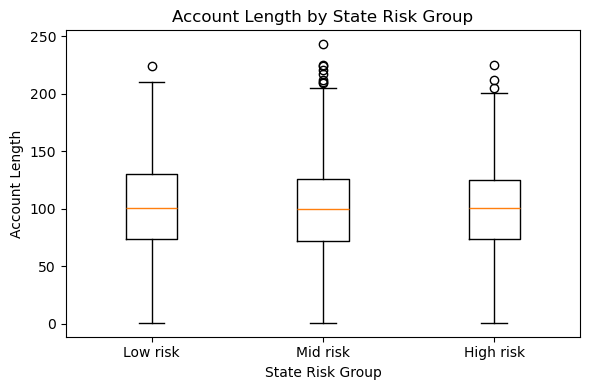

,count,mean,median,std
state_risk_group,,,,
Low risk,754,101.468170,101.0,39.175021
Mid risk,1284,100.560748,100.0,39.998658
High risk,628,99.724522,100.5,39.174442


In [54]:
# 지역과 가입기간

import pandas as pd
import matplotlib.pyplot as plt

# === 0) 데이터 로드 ===
df = pd.read_csv("churn-bigml-80.csv")

# === 1) Churn 이진화 ===
if df["Churn"].dtype == bool:
    df["Churn_bin"] = df["Churn"].astype(int)
else:
    df["Churn_bin"] = df["Churn"].astype(str).str.lower().map({"true": 1, "false": 0})

# === 2) State별 이탈률 기반 리스크 그룹 생성 ===
state_rate = df.groupby("State")["Churn_bin"].mean()

def risk_group(rate):
    if rate >= 0.20:
        return "High risk"
    elif rate >= 0.10:
        return "Mid risk"
    else:
        return "Low risk"

df["state_risk_group"] = df["State"].map(lambda s: risk_group(state_rate[s]))

# === 3) 지역 리스크 그룹별 가입기간(Account length) 비교 ===
order = ["Low risk", "Mid risk", "High risk"]
acct_data = [df[df["state_risk_group"] == g]["Account length"] for g in order]

plt.figure(figsize=(6, 4))
plt.boxplot(acct_data, labels=order)
plt.ylabel("Account Length")
plt.xlabel("State Risk Group")
plt.title("Account Length by State Risk Group")
plt.tight_layout()
plt.show()

# === (선택) 요약 통계 확인 ===
df.groupby("state_risk_group")["Account length"].agg(["count", "mean", "median", "std"]).loc[order]


/var/folders/zx/5ql37vbd32l6kwdp9gj2844m0000gn/T/ipykernel_69919/2911090761.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vmail_data, labels=order)


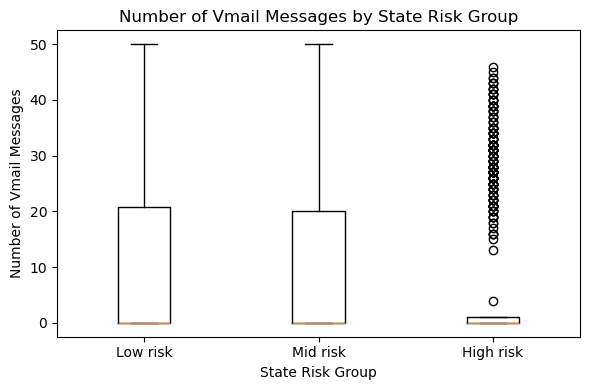

,count,mean,median,std
state_risk_group,,,,
Low risk,754,8.343501,0.0,13.833387
Mid risk,1284,8.154984,0.0,13.630412
High risk,628,7.363057,0.0,13.303788


In [ ]:
# 지역 리스크 그룹별 음성사서함 메시지 수

import pandas as pd
import matplotlib.pyplot as plt

# === 0) 데이터 로드 ===
df = pd.read_csv("churn-bigml-80.csv")

# === 1) Churn 이진화 ===
if df["Churn"].dtype == bool:
    df["Churn_bin"] = df["Churn"].astype(int)
else:
    df["Churn_bin"] = df["Churn"].astype(str).str.lower().map({"true": 1, "false": 0})

# === 2) State별 이탈률 기반 리스크 그룹 생성 ===
state_rate = df.groupby("State")["Churn_bin"].mean()

def risk_group(rate):
    if rate >= 0.20:
        return "High risk"
    elif rate >= 0.10:
        return "Mid risk"
    else:
        return "Low risk"

df["state_risk_group"] = df["State"].map(lambda s: risk_group(state_rate[s]))

# === 3) 지역 리스크 그룹별 음성사서함 메시지 수(Number vmail messages) 비교 ===
order = ["Low risk", "Mid risk", "High risk"]
vmail_data = [df[df["state_risk_group"] == g]["Number vmail messages"] for g in order]

plt.figure(figsize=(6, 4))
plt.boxplot(vmail_data, labels=order)
plt.ylabel("Number of Vmail Messages")
plt.xlabel("State Risk Group")
plt.title("Number of Vmail Messages by State Risk Group")
plt.tight_layout()
plt.show()

# === (선택) 요약 통계 확인 ===
df.groupby("state_risk_group")["Number vmail messages"].agg(["count", "mean", "median", "std"]).loc[order]


고위험 지역에서 일관되게 높았던 것

국제 전화요금제 사용

고객센터 문의 횟수

지역 리스크가 높아질수록 같이 증가

서로도 강하게 연결

이탈률과도 직접적으로 연결

우리가 모르는 것들:

지역별 요금 정책 차이   
네트워크 품질/커버리지    
고객센터 응대 품질의 지역 편차   
경쟁사 존재 여부   
지역별 고객 특성(출장, 해외 통화 수요 등)

지역 간 이탈률 차이는 관측되지만,
그 차이의 근본 원인은 현재 데이터로는 설명할 수 없다.

지역 리스크 그룹을 feature로 추가하면   
국제 요금제와 고객센터 문의만 사용한 모델보다   
이탈 예측 성능이 향상될 것이다.   


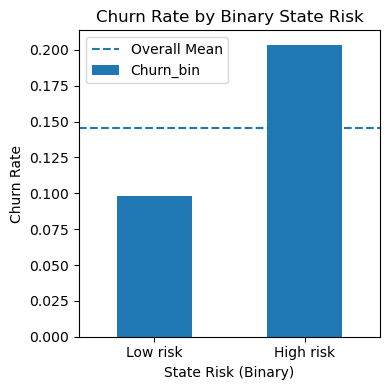

state_risk_bin
Low risk     0.097811
High risk    0.203488
Name: Churn_bin, dtype: float64

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# === 0) 데이터 로드 ===
df = pd.read_csv("churn-bigml-80.csv")

# === 1) Churn 이진화 ===
if df["Churn"].dtype == bool:
    df["Churn_bin"] = df["Churn"].astype(int)
else:
    df["Churn_bin"] = df["Churn"].astype(str).str.lower().map({"true": 1, "false": 0})

# === 2) State별 이탈률 + 전체 평균 ===
state_rate = df.groupby("State")["Churn_bin"].mean()
overall_rate = df["Churn_bin"].mean()

# === 3) 2개 리스크 그룹 생성 (전체 평균 기준) ===
df["state_risk_bin"] = df["State"].map(
    lambda s: "High risk" if state_rate[s] >= overall_rate else "Low risk"
)

# === 4) 2그룹 이탈률 계산 ===
risk_bin_churn = (
    df.groupby("state_risk_bin")["Churn_bin"]
      .mean()
      .reindex(["Low risk", "High risk"])
)

# === 5) 시각화 ===
plt.figure(figsize=(4, 4))
risk_bin_churn.plot(kind="bar")
plt.axhline(overall_rate, linestyle="--", label="Overall Mean")
plt.ylabel("Churn Rate")
plt.xlabel("State Risk (Binary)")
plt.title("Churn Rate by Binary State Risk")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

# (선택) 숫자 확인
risk_bin_churn


‘왜 이탈이 발생하는지’는 설명할 수 없고,
‘이탈이 더 자주 발생하는 환경인지 아닌지’는 설명할 수 있다.
다만 알 수 있는것은    
고이탈 지역에 속한 고객은   
저이탈 지역에 속한 고객보다   
이탈할 확률이 높다.   - 너무나 당연해...

예측가설1.    
고위험지역에 속한 고객은   
저위험지역에 속한 고객보다   
이탈할 확률이 높을 것이다.   

“이 고객은 고위험지역이고,   
국제요금제를 쓰고,고객센터 전화를 3번 했어.   
이 사람, 떠날 확률 얼마야?”     

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 데이터 로드
df = pd.read_csv("churn-bigml-80.csv")

# 이탈 이진화
df["Churn_bin"] = df["Churn"].astype(str).str.lower().map({"true": 1, "false": 0})

# 지역 이진 리스크 생성
state_rate = df.groupby("State")["Churn_bin"].mean()
overall_rate = df["Churn_bin"].mean()

df["state_risk_bin"] = df["State"].map(
    lambda s: 1 if state_rate[s] >= overall_rate else 0
)

# 핵심 변수
df["International_plan_bin"] = (df["International plan"] == "Yes").astype(int)

# 🔹 상호작용 변수 생성
df["risk_x_service"] = df["state_risk_bin"] * df["Customer service calls"]
df["risk_x_international"] = df["state_risk_bin"] * df["International_plan_bin"]

# 모델 입력 변수
features_no_interaction = [
    "International_plan_bin",
    "Customer service calls",
    "state_risk_bin"
]

features_with_interaction = features_no_interaction + [
    "risk_x_service",
    "risk_x_international"
]

X1 = df[features_no_interaction]
X2 = df[features_with_interaction]
y = df["Churn_bin"]

# Train / Test 분리
X1_tr, X1_te, y_tr, y_te = train_test_split(
    X1, y, test_size=0.2, random_state=42, stratify=y
)

X2_tr, X2_te, _, _ = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 학습
m1 = LogisticRegression(max_iter=1000)
m2 = LogisticRegression(max_iter=1000)

m1.fit(X1_tr, y_tr)
m2.fit(X2_tr, y_tr)

# 성능 비교
auc_no_inter = roc_auc_score(y_te, m1.predict_proba(X1_te)[:,1])
auc_inter = roc_auc_score(y_te, m2.predict_proba(X2_te)[:,1])

auc_no_inter, auc_inter


(0.7007281826360773, 0.7018527890238416)

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv("churn-bigml-80.csv")

# Churn 이진화
df["Churn_bin"] = df["Churn"].astype(str).str.lower().map({"true": 1, "false": 0})

# State → 이진 지역 리스크
state_rate = df.groupby("State")["Churn_bin"].mean()
overall_rate = df["Churn_bin"].mean()

df["state_risk_bin"] = df["State"].map(
    lambda s: "High risk" if state_rate[s] >= overall_rate else "Low risk"
)

# Area code별 이탈률 + 지역 리스크 분포
area_summary = (
    df.groupby(["Area code", "state_risk_bin"])["Churn_bin"]
      .mean()
      .unstack()
)

area_summary


state_risk_bin,High risk,Low risk
Area code,,
408,0.214744,0.075630
415,0.204429,0.102599
510,0.190164,0.109626


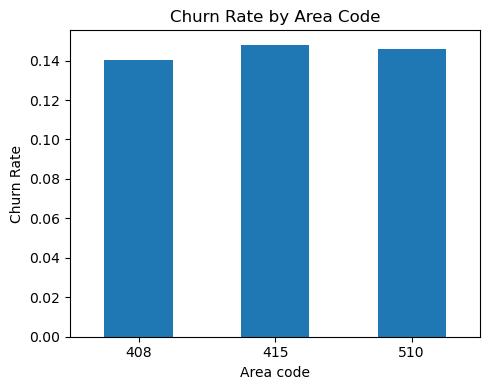

In [59]:
area_churn = df.groupby("Area code")["Churn_bin"].mean()

plt.figure(figsize=(5,4))
area_churn.plot(kind="bar")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Area Code")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [60]:
pd.crosstab(df["Area code"], df["state_risk_bin"], normalize="index")


state_risk_bin,High risk,Low risk
Area code,,
408,0.466368,0.533632
415,0.445372,0.554628
510,0.449190,0.550810


=== Count table (Area code x Risk) ===
state_risk_bin  High risk  Low risk
Area code                          
408                   312       357
415                   587       731
510                   305       374

=== Proportion table (row-normalized) ===
state_risk_bin  High risk  Low risk
Area code                          
408              0.466368  0.533632
415              0.445372  0.554628
510              0.449190  0.550810


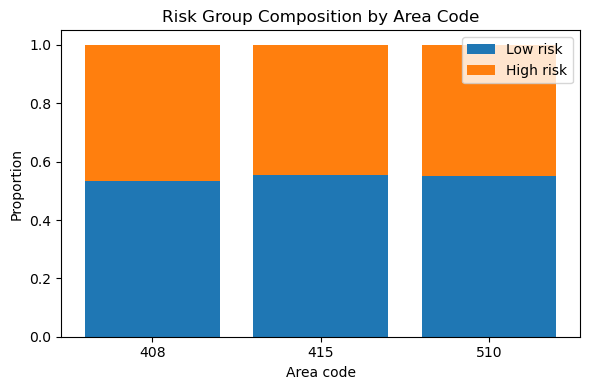

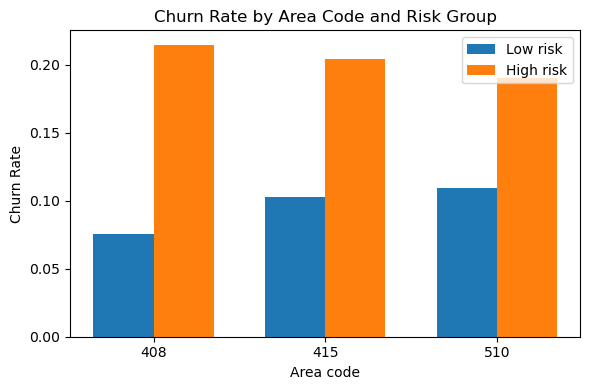

state_risk_bin,High risk,Low risk
Area code,,
408,0.214744,0.075630
415,0.204429,0.102599
510,0.190164,0.109626


In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# === 0) 데이터 로드 ===
df = pd.read_csv("churn-bigml-80.csv")

# === 1) Churn 이진화 ===
if df["Churn"].dtype == bool:
    df["Churn_bin"] = df["Churn"].astype(int)
else:
    df["Churn_bin"] = df["Churn"].astype(str).str.lower().map({"true": 1, "false": 0})

# === 2) State별 이탈률 → 2개 리스크 그룹(High/Low) 생성 ===
state_rate = df.groupby("State")["Churn_bin"].mean()
overall_rate = df["Churn_bin"].mean()

df["state_risk_bin"] = df["State"].map(
    lambda s: "High risk" if state_rate[s] >= overall_rate else "Low risk"
)

# === 3) (매칭 결과) Area code × 리스크 그룹 교차표 ===
ct_count = pd.crosstab(df["Area code"], df["state_risk_bin"])
ct_prop = pd.crosstab(df["Area code"], df["state_risk_bin"], normalize="index")  # 각 Area code 내 비율

print("=== Count table (Area code x Risk) ===")
print(ct_count)
print("\n=== Proportion table (row-normalized) ===")
print(ct_prop)

# === 4) 시각화 1: Area code별 High/Low risk 비율(스택 바) ===
ct_prop = ct_prop.reindex(sorted(ct_prop.index))  # 408, 415, 510 순으로 정렬(있으면)

plt.figure(figsize=(6, 4))
plt.bar(ct_prop.index.astype(str), ct_prop["Low risk"], label="Low risk")
plt.bar(
    ct_prop.index.astype(str),
    ct_prop["High risk"],
    bottom=ct_prop["Low risk"],
    label="High risk"
)
plt.ylabel("Proportion")
plt.xlabel("Area code")
plt.title("Risk Group Composition by Area Code")
plt.tight_layout()
plt.legend()
plt.show()

# === 5) 시각화 2: Area code × 리스크 그룹별 이탈률(그룹 막대) ===
churn_by_area_risk = (
    df.groupby(["Area code", "state_risk_bin"])["Churn_bin"]
      .mean()
      .unstack()
      .reindex(sorted(df["Area code"].unique()))
)

plt.figure(figsize=(6, 4))
x = range(len(churn_by_area_risk.index))
w = 0.35

plt.bar([i - w/2 for i in x], churn_by_area_risk["Low risk"], width=w, label="Low risk")
plt.bar([i + w/2 for i in x], churn_by_area_risk["High risk"], width=w, label="High risk")

plt.xticks(list(x), churn_by_area_risk.index.astype(str))
plt.ylabel("Churn Rate")
plt.xlabel("Area code")
plt.title("Churn Rate by Area Code and Risk Group")
plt.tight_layout()
plt.legend()
plt.show()

# (선택) 표 출력
churn_by_area_risk
